# Etape 1 - Importation des librairies et chargement des fichiers

## 1.1 - Importation des librairies et paramétrage

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la librairie NumPy
import numpy as np

#Importation de la librairie scikit-learn
from sklearn.preprocessing import StandardScaler #standardisation des données
from sklearn.decomposition import PCA #ACP
from sklearn.cluster import KMeans #Clustering par Kmeans
from sklearn.metrics import silhouette_score #Score de silhouette

#Importation de la librairie  scipy.cluster.hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster #Dendogram

#Importation de la librairie Matplotlib
import matplotlib.pyplot as plt

#Importation et chargement de la librairie Seaborn
import seaborn as sns
sns.set()

#Afficher toutes les colonnes d'un dataframe et monter le maximum de lignes affichées à 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1.2 - Chargement des fichiers

In [2]:
#Connecter au Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Importation du fichier Data_P11
df_P11 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data P11/Data_P11.csv', sep=',', decimal=".", index_col=0)

Mounted at /content/drive


# Etape 2 - Préparation des données

## 2.1 - Exploration

In [3]:
#Premières lignes
df_P11.head()

,Pop sans moyen de se nourrir sainement (en million) en 2022,Dispo viande volaille (kg/personne/an) en 2022,Import viande volaille (1000 t) en 2022,PIB/hab ($ PPA internationaux constants de 2021) en 2022,Pop totale (pour 1000) en 2022,Indice stabilité politique en 2022,TCAM PIB 2017-2022,TCAM Population 2017-2022,Taux urbanisation 2022,Taux autosuffisance 2022,Continent,Distance avec la France (km),Score Langue,Temp surface terrestre 2018 (°C),Taux pop accès électricité 2018,Indice perf log 2018,Indice corruption 2018,Indice état de droit 2018
Pays,,,,,,,,,,,,,,,,,,
Etats-Unis d'Amerique,16.2,53.75,191.0,72679.0,341534.045,0.01,1.352448,0.396443,81.774258,121.208163,America,7456.767,1,16.753366,100.0,3.89,1.292747,1.475687
Indonesie,129.8,14.88,0.0,13334.0,278830.529,-0.55,1.794604,0.602637,57.642345,100.192771,Asia,11576.700,0,27.874066,98.5,3.15,-0.299604,-0.314401
Pakistan,144.4,8.13,0.0,5526.0,243700.667,-1.84,1.346799,1.258440,33.415111,100.050480,Asia,6070.600,1,33.248080,93.4,2.42,-0.801857,-0.683650
Nigeria,173.3,1.60,0.0,5553.0,223150.896,-1.78,-0.252127,1.558575,52.008688,100.000000,Africa,4320.865,1,33.811945,56.5,2.53,-1.083862,-0.917606
Bresil,52.4,48.20,5.0,18554.0,210306.415,-0.40,0.655127,0.386506,90.190165,144.895946,America,8681.180,0,28.685798,99.7,2.99,-0.480954,-0.302343


In [4]:
#Dernières lignes
df_P11.tail()

,Pop sans moyen de se nourrir sainement (en million) en 2022,Dispo viande volaille (kg/personne/an) en 2022,Import viande volaille (1000 t) en 2022,PIB/hab ($ PPA internationaux constants de 2021) en 2022,Pop totale (pour 1000) en 2022,Indice stabilité politique en 2022,TCAM PIB 2017-2022,TCAM Population 2017-2022,Taux urbanisation 2022,Taux autosuffisance 2022,Continent,Distance avec la France (km),Score Langue,Temp surface terrestre 2018 (°C),Taux pop accès électricité 2018,Indice perf log 2018,Indice corruption 2018,Indice état de droit 2018
Pays,,,,,,,,,,,,,,,,,,
Montenegro,0.1,21.67,11.0,25429.0,614.648,-0.14,1.609454,-0.126400,69.773269,15.384615,Europe,1429.045,0,14.812275,100.0,2.75,-0.014758,0.002768
Malte,0.0,25.50,10.0,57782.0,528.192,0.91,1.635555,1.746519,78.411449,28.571429,Europe,1545.199,1,25.997609,100.0,2.81,0.547124,1.019972
Bahamas,0.0,65.45,22.0,34343.0,397.538,0.88,0.549743,0.256055,86.996463,21.428571,America,7298.163,1,27.716980,100.0,2.53,1.096057,0.068974
Islande,0.0,31.31,2.0,65475.0,380.356,1.25,0.326259,1.465351,86.050437,83.333333,Europe,2468.378,0,1.437087,100.0,3.23,1.805603,1.679251
Sao Tome-et-Principe,0.1,14.41,2.0,5632.0,226.305,0.46,0.284771,1.284028,76.151212,33.333333,Africa,5172.648,0,25.091597,71.0,2.65,0.152903,-0.713973


In [5]:
#Dimension
df_P11.shape

(123, 18)

In [6]:
#Caractéristiques générales
df_P11.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, Etats-Unis d'Amerique to Sao Tome-et-Principe
Data columns (total 18 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Pop sans moyen de se nourrir sainement (en million) en 2022  123 non-null    float64
 1   Dispo viande volaille (kg/personne/an) en 2022               123 non-null    float64
 2   Import viande volaille (1000 t) en 2022                      123 non-null    float64
 3   PIB/hab ($ PPA internationaux constants de 2021) en 2022     123 non-null    float64
 4   Pop totale (pour 1000) en 2022                               123 non-null    float64
 5   Indice stabilité politique en 2022                           123 non-null    float64
 6   TCAM PIB 2017-2022                                           123 non-null    float64
 7   TCAM Population 2017-2022                       

In [7]:
#Valeurs manquantes
df_P11.isna().mean()

,0
Pop sans moyen de se nourrir sainement (en million) en 2022,0.0
Dispo viande volaille (kg/personne/an) en 2022,0.0
Import viande volaille (1000 t) en 2022,0.0
PIB/hab ($ PPA internationaux constants de 2021) en 2022,0.0
Pop totale (pour 1000) en 2022,0.0
Indice stabilité politique en 2022,0.0
TCAM PIB 2017-2022,0.0
TCAM Population 2017-2022,0.0
Taux urbanisation 2022,0.0
Taux autosuffisance 2022,0.0


In [8]:
#Lignes en double
df_P11.duplicated().sum()

np.int64(0)

In [9]:
#Dispertion globale
df_P11.describe(include='all')

,Pop sans moyen de se nourrir sainement (en million) en 2022,Dispo viande volaille (kg/personne/an) en 2022,Import viande volaille (1000 t) en 2022,PIB/hab ($ PPA internationaux constants de 2021) en 2022,Pop totale (pour 1000) en 2022,Indice stabilité politique en 2022,TCAM PIB 2017-2022,TCAM Population 2017-2022,Taux urbanisation 2022,Taux autosuffisance 2022,Continent,Distance avec la France (km),Score Langue,Temp surface terrestre 2018 (°C),Taux pop accès électricité 2018,Indice perf log 2018,Indice corruption 2018,Indice état de droit 2018
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,11.501626,22.513902,100.552846,27325.308943,34590.173967,-0.124228,0.922046,0.805396,63.416280,81.012131,NaN,5282.989287,0.560976,24.329792,86.502439,2.913415,-0.046098,-0.009245
std,26.707671,15.452779,191.838440,25570.930445,57197.790541,0.835775,1.433811,0.783115,20.677703,43.032184,NaN,3730.001223,0.780357,9.462774,23.986497,0.550654,0.995476,0.958742
min,0.000000,0.840000,0.000000,1386.000000,226.305000,-2.780000,-4.747169,-0.992988,17.334204,0.000000,NaN,473.730400,0.000000,-3.754938,14.400000,2.050000,-1.648251,-2.054641
25%,0.300000,9.845000,4.000000,6312.500000,4802.931500,-0.630000,0.181835,0.309897,49.823971,63.518971,NaN,1828.417500,0.000000,16.720306,86.450000,2.530000,-0.783857,-0.710148
50%,1.700000,20.740000,25.000000,18459.000000,11503.606000,-0.100000,0.986312,0.763461,66.482801,89.940828,NaN,4587.869000,0.000000,26.657709,99.800000,2.790000,-0.340440,-0.224594
75%,10.100000,31.610000,98.500000,42238.000000,36482.046500,0.555000,1.744704,1.405015,81.115223,100.000000,NaN,7879.909000,1.000000,30.406728,100.000000,3.275000,0.541407,0.640509


## 2.2 - Sélection des données

In [10]:
#Dimensions initiales
df_P11.shape

(123, 18)

In [11]:
#Sélection des variables
cols = [
    'Pop sans moyen de se nourrir sainement (en million) en 2022',
    'Dispo viande volaille (kg/personne/an) en 2022',
    'Import viande volaille (1000 t) en 2022',
    'PIB/hab ($ PPA internationaux constants de 2021) en 2022',
    'Pop totale (pour 1000) en 2022',
    'Indice stabilité politique en 2022',
    'TCAM PIB 2017-2022',
    'TCAM Population 2017-2022',
    'Taux urbanisation 2022',
    'Taux autosuffisance 2022',
    'Distance avec la France (km)',
    'Temp surface terrestre 2018 (°C)',
    'Taux pop accès électricité 2018',
    'Indice perf log 2018',
    'Indice corruption 2018',
    'Indice état de droit 2018'
]

On ne prend ni 'Continent' ni 'Score Langue' qui sont des variables qualitatives qui ne peuvent être traitées dans l'analyse ACP.

In [12]:
#Création d'un nouveau dataframe avec la sélection
df_acp = df_P11[cols]
df_acp.head()

,Pop sans moyen de se nourrir sainement (en million) en 2022,Dispo viande volaille (kg/personne/an) en 2022,Import viande volaille (1000 t) en 2022,PIB/hab ($ PPA internationaux constants de 2021) en 2022,Pop totale (pour 1000) en 2022,Indice stabilité politique en 2022,TCAM PIB 2017-2022,TCAM Population 2017-2022,Taux urbanisation 2022,Taux autosuffisance 2022,Distance avec la France (km),Temp surface terrestre 2018 (°C),Taux pop accès électricité 2018,Indice perf log 2018,Indice corruption 2018,Indice état de droit 2018
Pays,,,,,,,,,,,,,,,,
Etats-Unis d'Amerique,16.2,53.75,191.0,72679.0,341534.045,0.01,1.352448,0.396443,81.774258,121.208163,7456.767,16.753366,100.0,3.89,1.292747,1.475687
Indonesie,129.8,14.88,0.0,13334.0,278830.529,-0.55,1.794604,0.602637,57.642345,100.192771,11576.700,27.874066,98.5,3.15,-0.299604,-0.314401
Pakistan,144.4,8.13,0.0,5526.0,243700.667,-1.84,1.346799,1.258440,33.415111,100.050480,6070.600,33.248080,93.4,2.42,-0.801857,-0.683650
Nigeria,173.3,1.60,0.0,5553.0,223150.896,-1.78,-0.252127,1.558575,52.008688,100.000000,4320.865,33.811945,56.5,2.53,-1.083862,-0.917606
Bresil,52.4,48.20,5.0,18554.0,210306.415,-0.40,0.655127,0.386506,90.190165,144.895946,8681.180,28.685798,99.7,2.99,-0.480954,-0.302343


In [13]:
#Dimensions du nouveau dataframe
df_acp.shape

(123, 16)

## 2.3 - Séparation des données

In [14]:
#Matrice X
X = df_acp.values
type(X)

numpy.ndarray

In [15]:
#Dimensions de X
X.shape

(123, 16)

In [16]:
#Enregistrement du nom des pays
observations = df_acp.index
observations

Index(['Etats-Unis d'Amerique', 'Indonesie', 'Pakistan', 'Nigeria', 'Bresil',
       'Bangladesh', 'Federation de Russie', 'Mexique', 'Philippines',
       'Egypte',
       ...
       'Chypre', 'Maurice', 'Fidji', 'Comores', 'Luxembourg', 'Montenegro',
       'Malte', 'Bahamas', 'Islande', 'Sao Tome-et-Principe'],
      dtype='object', name='Pays', length=123)

In [17]:
#Enregistrement du nom des variables
features = df_acp.columns
features

Index(['Pop sans moyen de se nourrir sainement (en million) en 2022',
       'Dispo viande volaille (kg/personne/an) en 2022',
       'Import viande volaille (1000 t) en 2022',
       'PIB/hab ($ PPA internationaux constants de 2021) en 2022',
       'Pop totale (pour 1000) en 2022', 'Indice stabilité politique en 2022',
       'TCAM PIB 2017-2022', 'TCAM Population 2017-2022',
       'Taux urbanisation 2022', 'Taux autosuffisance 2022',
       'Distance avec la France (km)', 'Temp surface terrestre 2018 (°C)',
       'Taux pop accès électricité 2018', 'Indice perf log 2018',
       'Indice corruption 2018', 'Indice état de droit 2018'],
      dtype='object')

# Etape 3 - Variables et composantes

## 3.1 - Scaling

In [18]:
#Instance
scaler = StandardScaler()

In [19]:
#Ajustement et transformation
X_scaled = scaler.fit_transform(X)

In [20]:
#Vérification de la moyenne et de l'écart type
pd.DataFrame(X_scaled).describe().round(2).loc[['mean', 'std']]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
mean,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.2 - Recherche du nombre de composantes par l'éboulis des valeurs propres

### 3.3.1 - Composantes

In [21]:
#Nombre de composantes
n_components = X_scaled.shape[1]

In [22]:
#Instancier
pca = PCA(n_components=n_components)

In [23]:
#Entraînement
pca.fit(X_scaled)

PCA(n_components=16)

### 3.3.2 - Variance et scree plot

In [24]:
#Variance par composante
pca.explained_variance_ratio_

array([0.38147578, 0.12439781, 0.10273599, 0.08320775, 0.06804226,
       0.05093387, 0.04703968, 0.03764817, 0.02407272, 0.01980319,
       0.01732391, 0.01263484, 0.01152818, 0.00864343, 0.0079995 ,
       0.00251292])

In [25]:
#Enregistrement
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([38.15, 12.44, 10.27,  8.32,  6.8 ,  5.09,  4.7 ,  3.76,  2.41,
        1.98,  1.73,  1.26,  1.15,  0.86,  0.8 ,  0.25])

In [26]:
#Somme cumulée
scree_cum = scree.cumsum().round()
scree_cum

array([ 38.,  51.,  61.,  69.,  76.,  81.,  86.,  90.,  92.,  94.,  96.,
        97.,  98.,  99., 100., 100.])

In [27]:
#Nouvelle variable
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

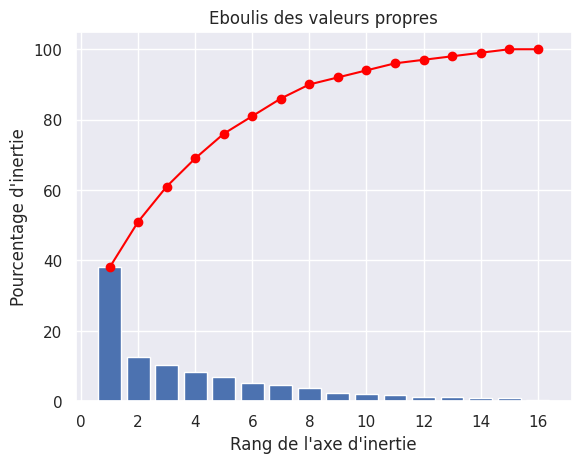

In [28]:
#Graphique
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("Rang de l'axe d'inertie")
plt.ylabel("Pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show()

In [29]:
#Pourcentage d'inertie à 5 composants
cumul_variance_5 = pca.explained_variance_ratio_[:5].sum() * 100
print(f"Le pourcentage d'inertie expliquée par les 5 premières composantes est de : {cumul_variance_5:.2f} %")

Le pourcentage d'inertie expliquée par les 5 premières composantes est de : 75.99 %


Nous nous baserons sur 5 composantes qui résument 76% de l'inertie totale.

### 3.3.3 - Les composantes

In [30]:
#Variable PCS
pcs = pca.components_[:5]
pcs

array([[-0.17501924,  0.21509981,  0.11534665,  0.35520728, -0.06456489,
         0.30896256,  0.08672451, -0.23659337,  0.27576893,  0.11320447,
        -0.1124061 , -0.24972945,  0.27776642,  0.34409256,  0.35790745,
         0.36466961],
       [ 0.53013288,  0.0517999 ,  0.18397116,  0.02394209,  0.64502358,
        -0.21463981,  0.08813976, -0.07142691,  0.020876  ,  0.35902948,
         0.13832314,  0.04858626,  0.13188505,  0.19434707,  0.00771274,
         0.02837912],
       [-0.08594944,  0.48795771,  0.25587805, -0.04195891,  0.01092457,
        -0.02637947, -0.48448858,  0.04383398,  0.38398466, -0.18653672,
         0.37260267,  0.30462214,  0.13771181, -0.07842637, -0.05183226,
        -0.0902254 ],
       [ 0.13079766, -0.26820646,  0.39729672,  0.21417325,  0.04529749,
         0.04253523, -0.22085459,  0.51934243,  0.01287678, -0.21727535,
        -0.16862912,  0.12653395, -0.38825096,  0.2122678 ,  0.2332427 ,
         0.20704682],
       [ 0.04719917,  0.07660314, -0

In [31]:
#En dataframe
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.175019,0.215100,0.115347,0.355207,-0.064565,0.308963,0.086725,-0.236593,0.275769,0.113204,-0.112406,-0.249729,0.277766,0.344093,0.357907,0.364670
1,0.530133,0.051800,0.183971,0.023942,0.645024,-0.214640,0.088140,-0.071427,0.020876,0.359029,0.138323,0.048586,0.131885,0.194347,0.007713,0.028379
2,-0.085949,0.487958,0.255878,-0.041959,0.010925,-0.026379,-0.484489,0.043834,0.383985,-0.186537,0.372603,0.304622,0.137712,-0.078426,-0.051832,-0.090225
3,0.130798,-0.268206,0.397297,0.214173,0.045297,0.042535,-0.220855,0.519342,0.012877,-0.217275,-0.168629,0.126534,-0.388251,0.212268,0.233243,0.207047
4,0.047199,0.076603,-0.386606,-0.025690,-0.027602,0.338558,0.047059,0.243960,-0.230230,0.171105,0.660674,0.074409,-0.191340,0.062955,0.232060,0.214311


In [32]:
#Ajout des noms de variables
pcs.columns = features
x_list_select = range(1,6)
pcs.index = [f"F{i}" for i in x_list_select]
pcs.round(2)

,Pop sans moyen de se nourrir sainement (en million) en 2022,Dispo viande volaille (kg/personne/an) en 2022,Import viande volaille (1000 t) en 2022,PIB/hab ($ PPA internationaux constants de 2021) en 2022,Pop totale (pour 1000) en 2022,Indice stabilité politique en 2022,TCAM PIB 2017-2022,TCAM Population 2017-2022,Taux urbanisation 2022,Taux autosuffisance 2022,Distance avec la France (km),Temp surface terrestre 2018 (°C),Taux pop accès électricité 2018,Indice perf log 2018,Indice corruption 2018,Indice état de droit 2018
F1,-0.18,0.22,0.12,0.36,-0.06,0.31,0.09,-0.24,0.28,0.11,-0.11,-0.25,0.28,0.34,0.36,0.36
F2,0.53,0.05,0.18,0.02,0.65,-0.21,0.09,-0.07,0.02,0.36,0.14,0.05,0.13,0.19,0.01,0.03
F3,-0.09,0.49,0.26,-0.04,0.01,-0.03,-0.48,0.04,0.38,-0.19,0.37,0.30,0.14,-0.08,-0.05,-0.09
F4,0.13,-0.27,0.40,0.21,0.05,0.04,-0.22,0.52,0.01,-0.22,-0.17,0.13,-0.39,0.21,0.23,0.21
F5,0.05,0.08,-0.39,-0.03,-0.03,0.34,0.05,0.24,-0.23,0.17,0.66,0.07,-0.19,0.06,0.23,0.21


In [33]:
#Modification de l'orientation du tableau pour la lecture
pcs.T

,F1,F2,F3,F4,F5
Pop sans moyen de se nourrir sainement (en million) en 2022,-0.175019,0.530133,-0.085949,0.130798,0.047199
Dispo viande volaille (kg/personne/an) en 2022,0.215100,0.051800,0.487958,-0.268206,0.076603
Import viande volaille (1000 t) en 2022,0.115347,0.183971,0.255878,0.397297,-0.386606
PIB/hab ($ PPA internationaux constants de 2021) en 2022,0.355207,0.023942,-0.041959,0.214173,-0.025690
Pop totale (pour 1000) en 2022,-0.064565,0.645024,0.010925,0.045297,-0.027602
Indice stabilité politique en 2022,0.308963,-0.214640,-0.026379,0.042535,0.338558
TCAM PIB 2017-2022,0.086725,0.088140,-0.484489,-0.220855,0.047059
TCAM Population 2017-2022,-0.236593,-0.071427,0.043834,0.519342,0.243960
Taux urbanisation 2022,0.275769,0.020876,0.383985,0.012877,-0.230230
Taux autosuffisance 2022,0.113204,0.359029,-0.186537,-0.217275,0.171105


<Axes: >

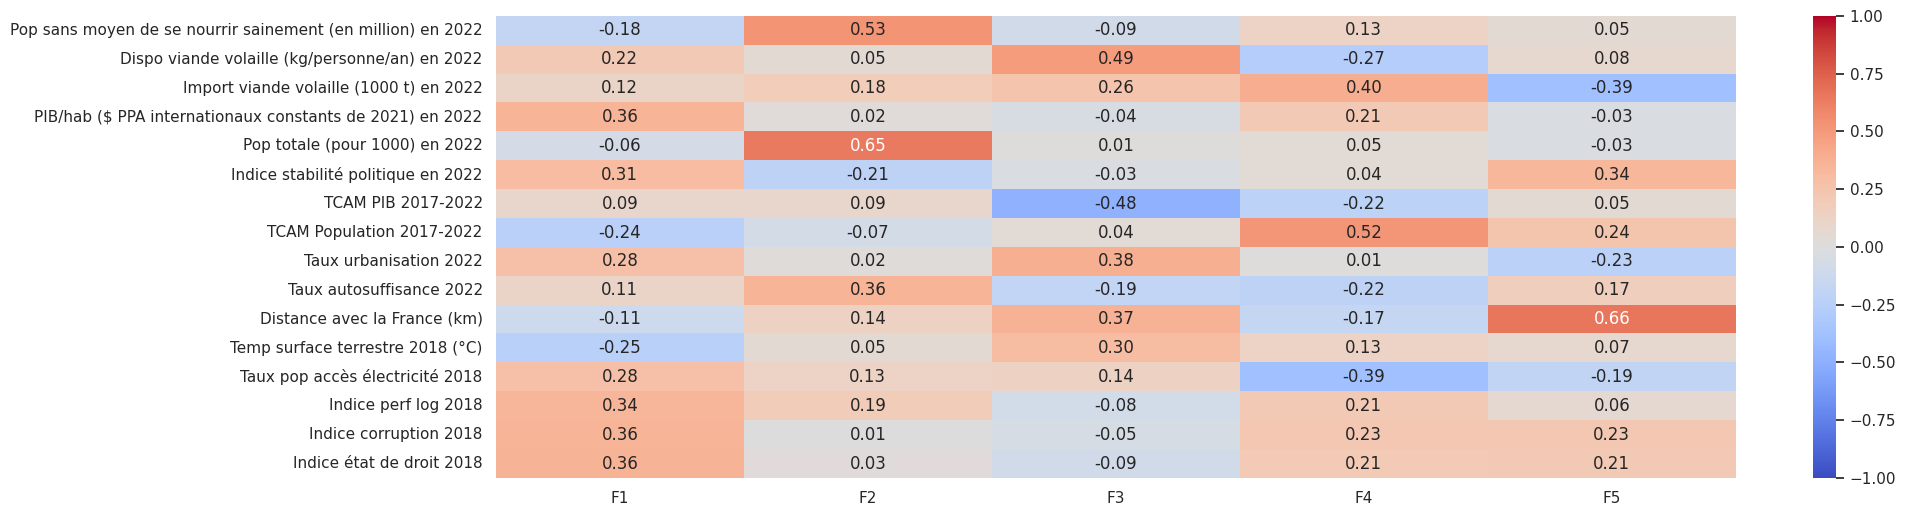

In [34]:
#Graphique heatmap pour le visuel
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

In [35]:
#Représentation de chaque axe
poids_relatifs = pca.explained_variance_ratio_ * 100

for i in range(5):
    print(f"F{i+1} : {poids_relatifs[i]:.2f} % de la variance totale")

print(f"\nTotal cumulé (F1 à F5) : {poids_relatifs[:5].sum():.2f} %")

F1 : 38.15 % de la variance totale
F2 : 12.44 % de la variance totale
F3 : 10.27 % de la variance totale
F4 : 8.32 % de la variance totale
F5 : 6.80 % de la variance totale

Total cumulé (F1 à F5) : 75.99 %


**F1 : Axe de la Maturité Économique et Institutionnelle (38.15 %)**

Variables dominantes à corrélations positives :

* PIB/hab (0,36)
* Indice état de droit (0,36)
* Indice corruption (0,36)
* Indice perf log (0,34)
* Indice de stabilité politique en 2022 (0.31)

Cet axe oppose les pays développés, stables et transparents aux pays en difficulté institutionnelle. Un score élevé sur F1 indique un marché où la logistique est fiable, les risques juridiques sont faibles et le pouvoir d'achat est élevé.

Conclusion :
C'est le pilier de la sécurité des paiements et de la chaîne du froid.
Le score F1 doit être positif et élevé.


---


**F2 : Axe de la Masse Démographique et de la Fragilité (12.44 %)**

Variables dominantes à corrélations positives :
* Pop totale (0,65)
* Pop sans moyen de se nourrir sainement (0,53)

Cet axe identifie la corrélation très forte entre la population totale et l'impossibilité de se nourrir sainement suggère que celui-ci capte des pays à forte population mais avec des poches de pauvreté importantes.

Conclusion :
C'est l'axe du volume potentiel, mais il nécessite une vigilance sur le segment de clientèle visé (le Bio étant un produit premium).
Le score F2 doit être équilibré et proche de 0.


---


**F3 : Axe du Profil de Consommation, Urbanisation et contraintes géographiques et climatiques (10.27 %)**

Variables dominantes à corrélations positives :
* Dispo viande volaille (0.49)
* Taux urbanisation (0.38)
* Distance avec la France (0.37)
* Température à la surface (0.30)

Variables dominantes à corrélations négatives :
* TCAM PIB (-0.48)

Cet axe isole les pays où la consommation de poulet est déjà ancrée dans les habitudes pour une population plutôt urbaine. La corrélation négative avec le TCAM PIB suggère que ce sont des marchés "installés" dont la croissance économique est stable mais plus lente. On peut également noter une corélation positive avec la distance avec la France et la Température.

Conclusion :
C'est l'axe de la consommation et de l'urbanisation mais aussi de la croissance économique en corrélation négative ainsi que des contraintes géographiques et climatiques.
Le score F3 doit être autour de 0 pour avoir un équilibre entre l'opportunité commerciale et la faisabilité logistique.



---


**F4 : Axe de l'Opportunité de Marché (Besoin d'Importation et Population) (8.32 %)**

Variables dominantes à corrélations positives :
* TCAM Population (0.52)
* Import viande volaille (0.40)

Variables dominantes à corrélations négatives :
* Taux accès à l'électricité (-0.39)

C'est l'axe qui met en relation la croissance de la population et l'importation de viande de volaille, deux indicateurs en faveurs du développement commercial, mais ayant une corrélation négative avec l'accès à l'électricité ce qui constitue un risque logistique non négligeable

Conclusion :
C'est l'axe du "besoin immédiat", un score élevé ici désigne un pays qui doit acheter à l'extérieur pour nourrir sa population mais qui présente un risque logistique due à un accès limité à l'électricité et des difficultés pour respecter la chaîne du froid.
Le score F4 doit être positif pour que le pays ait un intérêt commercial mais pas trop élevé pour limiter le risque logistique.


---


F5 : Axe de la Distance Géographique et Stabilité (6,80 %)
**texte en gras**
Variables dominantes à corrélations positives :
Distance avec la France (0.66)
Indice de stabilité politique en 2022 (0.34)

Variables dominantes à corrélations négatives :
Import de viande de volaille (-0.39)

Cet axe est essentiellement géographique et géopolitique. Il isole les pays très éloignés de la France en montrant tout de même un corrélation positive avec la stabilité politique. La corrélation négative avec l'import de viande de volaille est un élément important de la décision de développement commercial.

Conclusion :
C'est l'axe du transport, il permet de procéder à la sélection finale en retirant les pays trop éloignés de la France générant donc des frais logistiques et un impact carbone importants (à prendre en compte pour une entreprise dans la vente de produits bios).
Un score faible est préconisé afin de faire une sélection à proposer à la direction.


---


**Synthèse pour la sélection des pays cibles**

Pour maximiser les chances de succès de "La poule qui chante", nous devons rechercher des pays qui cumulent :

* Un score F1 élevé  : richesse, sécurité et performance logistique.

* Un score F2 proche de 0 : population de bonne taille avec accès à une alimentation de qualité.

* Un score F3 proche de 0 : population en stabilité économique, habituée à consommer de la volaille dans un pays peu éloigné de la France et avec une température au sol pas trop élevée.

* Un score F4 positif mais pas trop élevé : importateur de viande de volaille avec population en croissance tout en limitant le risque logistique.

* Un score F5 faible : un éloignelment limité avec la France en conservant une certaine stabilité politique et un atrait pour l'importation de viande de volaille (à utiliser en dernier recours pour choisir entre les pays sélectionnés).
    

# Etape 4 - Graphiques de corrélation

## 4.1 - Déclaration de la formule

In [36]:
def correlation_graph(pca,
                      x_y,
                      features) :

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.02,
                pca.components_[y, i] + 0.02,
                features[i],
                fontsize=8,
                ha='left',
                va='center')

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

## 4.2 - Graphique de corrélation F1/F2

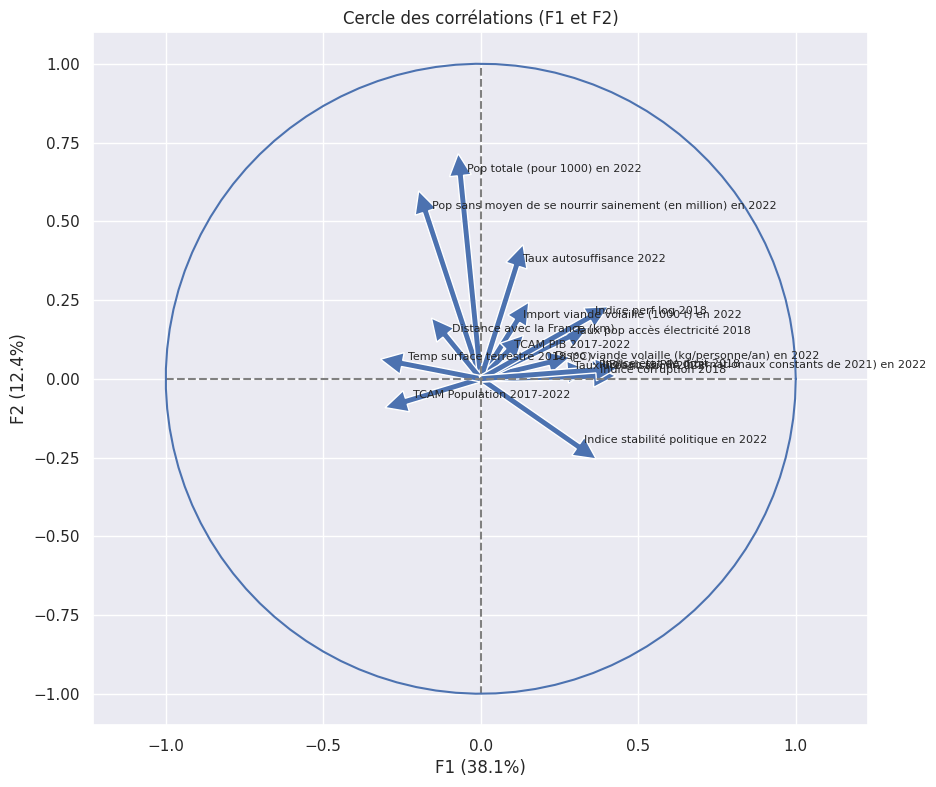

In [37]:
#Application à F1 et F2
x_y = (0,1)

#Formule
correlation_graph(pca, x_y, features)

## 4.3 - Graphique de corrélation F3/F4

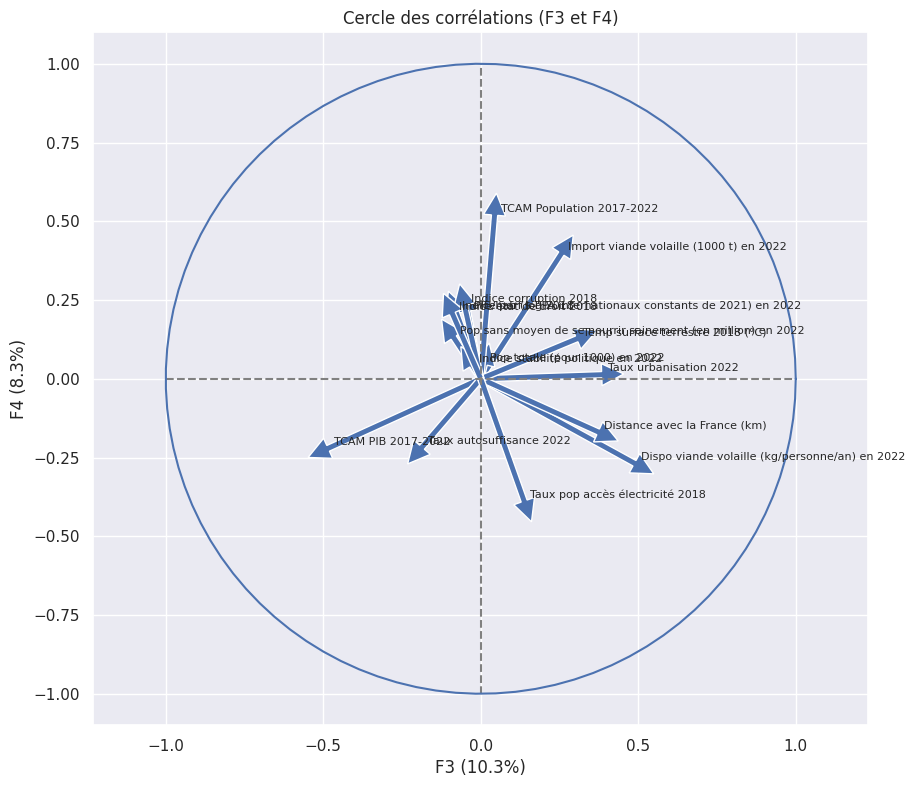

In [38]:
#Application à F3 et F4
x_y = (2,3)

#Formule
correlation_graph(pca, x_y, features)

## 4.4 - Graphique de corrélation F1/F5

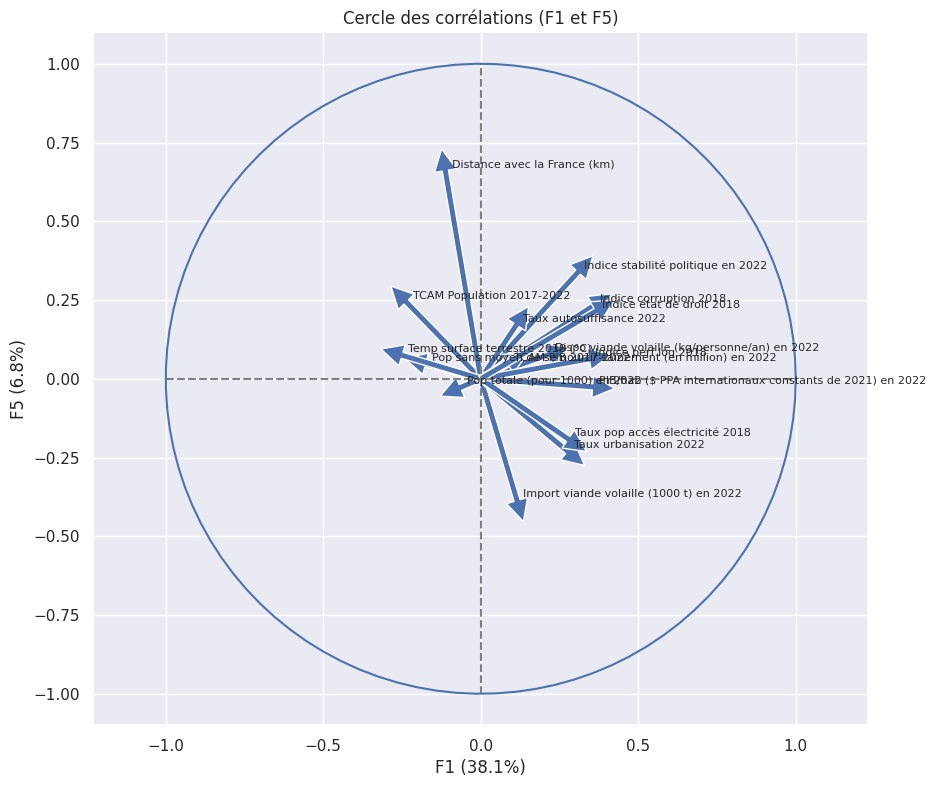

In [39]:
#Application à F1 et F5
x_y = (0,4)

#Formule
correlation_graph(pca, x_y, features)

# Etape 5 - Projections des individus

## 5.1 - Déclaration de la formule

In [40]:
#Coordonnées des individus
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[ 3.25211935,  4.70588185,  0.77553748,  0.36318376,  0.65986928,
        -0.81469364, -0.9094236 , -0.03529431, -1.34948805, -1.0860355 ,
        -0.79330761, -0.60227775,  2.54942068, -0.67627688, -1.01759206,
         0.01492472],
       [-1.69244786,  5.71638017, -0.35092083, -0.27769636,  1.15498741,
        -1.62165617, -1.54707958, -0.56760577,  0.90034067,  0.1562632 ,
         0.46568032,  0.13893788,  0.16634825,  0.01922227,  0.14087013,
        -0.21771115],
       [-3.7971774 ,  5.31966604, -1.06985817,  0.16793805, -0.07204828,
        -1.27213448, -1.57220956,  0.31350301,  0.6867176 ,  0.38599547,
        -0.57870903,  0.76015301, -0.73565536,  0.02406873, -0.26697664,
        -0.01167751],
       [-4.48515625,  5.28166624, -0.81877339,  1.48205155, -0.30289087,
        -0.59728185, -2.5533545 ,  0.70079561,  0.96797313, -0.35800657,
         0.42606686,  0.87804041, -1.04950964,  0.59189097,  0.46864065,
         0.0243455 ],
       [-0.03918568,  3.68322006,  1

In [41]:
#Déclaration de la formule
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='7', ha='left',va='center')

    # Titre et affichage
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

## 5.2 - Projection des individus

### 5.2.1 - F1/F2

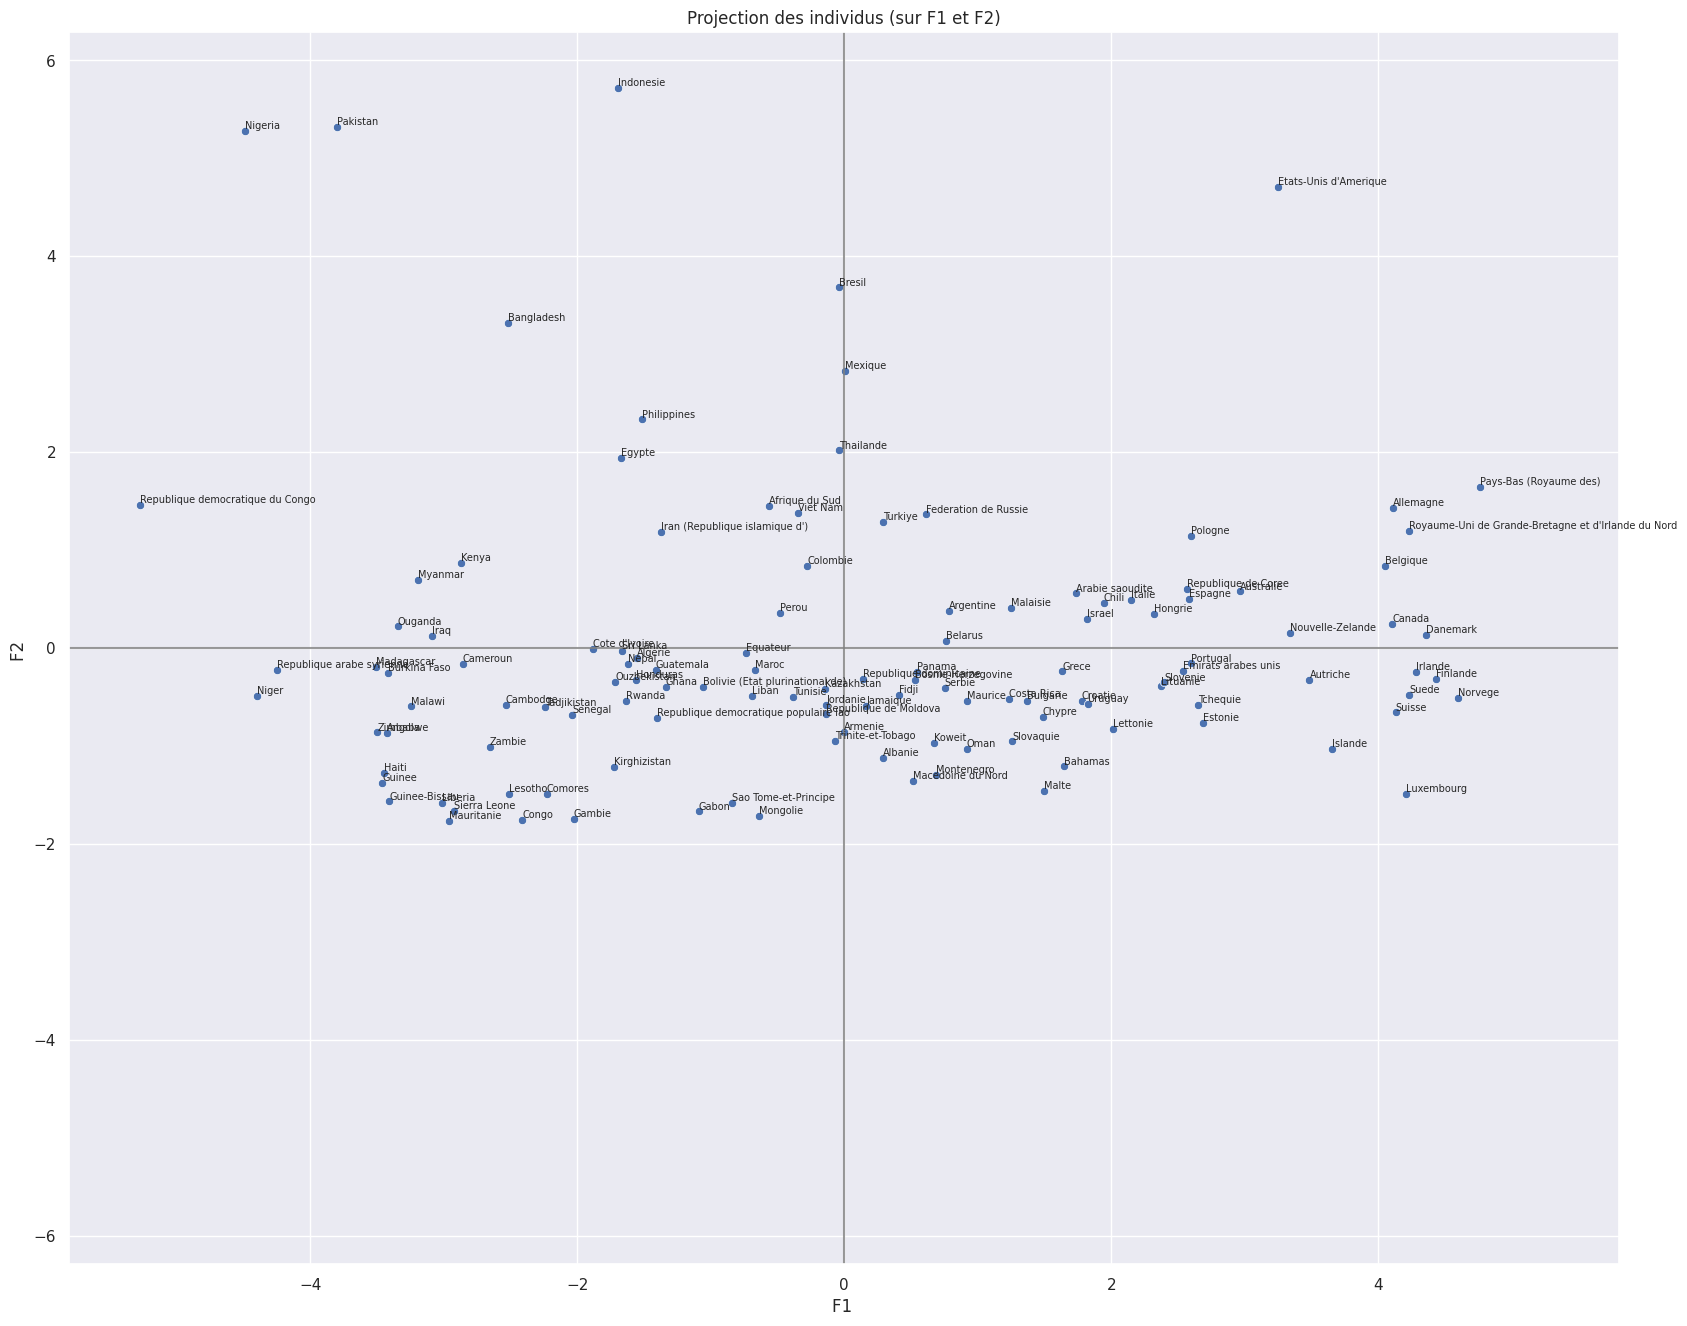

In [42]:
#Paramétrage des composantes
x_y = [0,1]

#Affichage du graph
display_factorial_planes(X_proj, x_y, labels=observations, figsize=[20,16])

## 5.2.2 - F3/F4

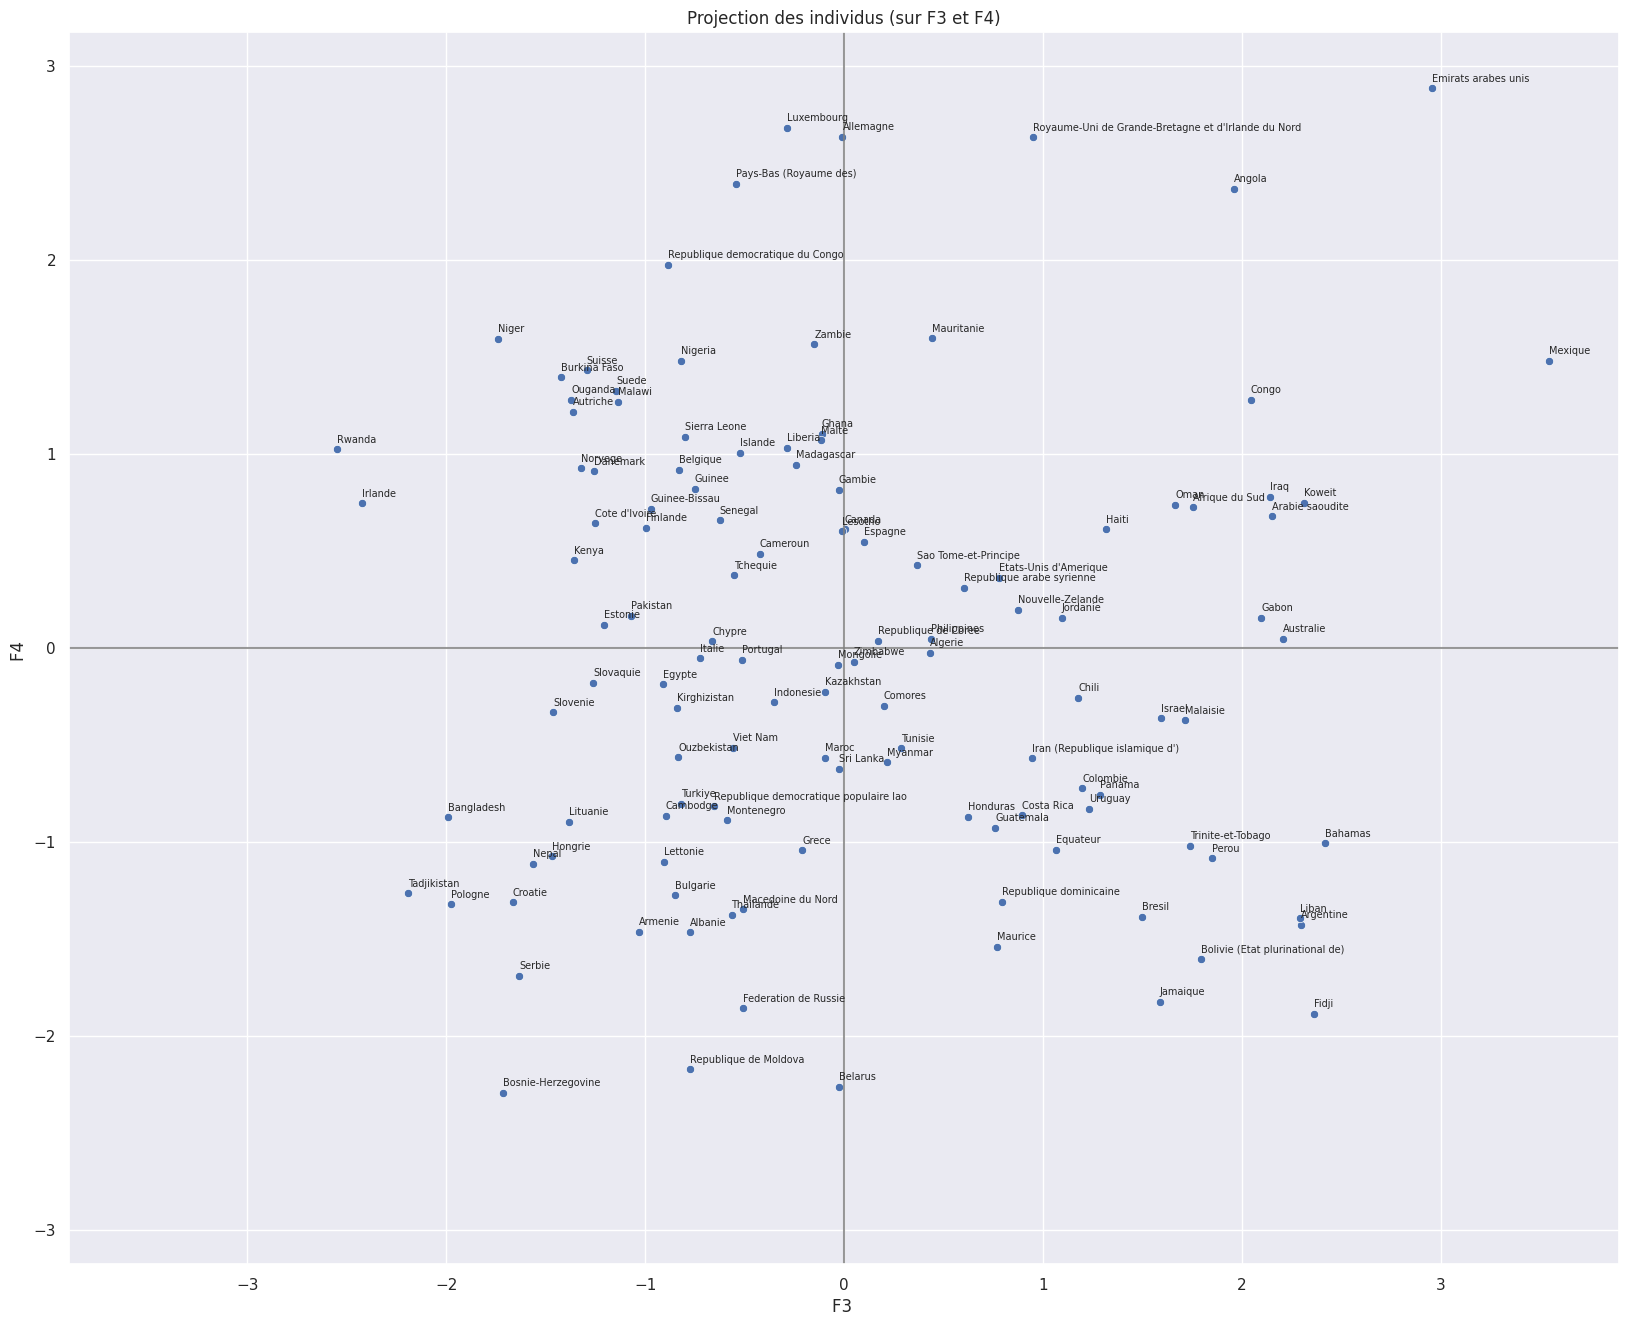

In [43]:
#Paramétrage des composantes
x_y = [2,3]

#Affichage du graph avec continents
display_factorial_planes(X_proj, x_y, labels=observations, figsize=[20,16])

## 5.2.3 - F1/F5

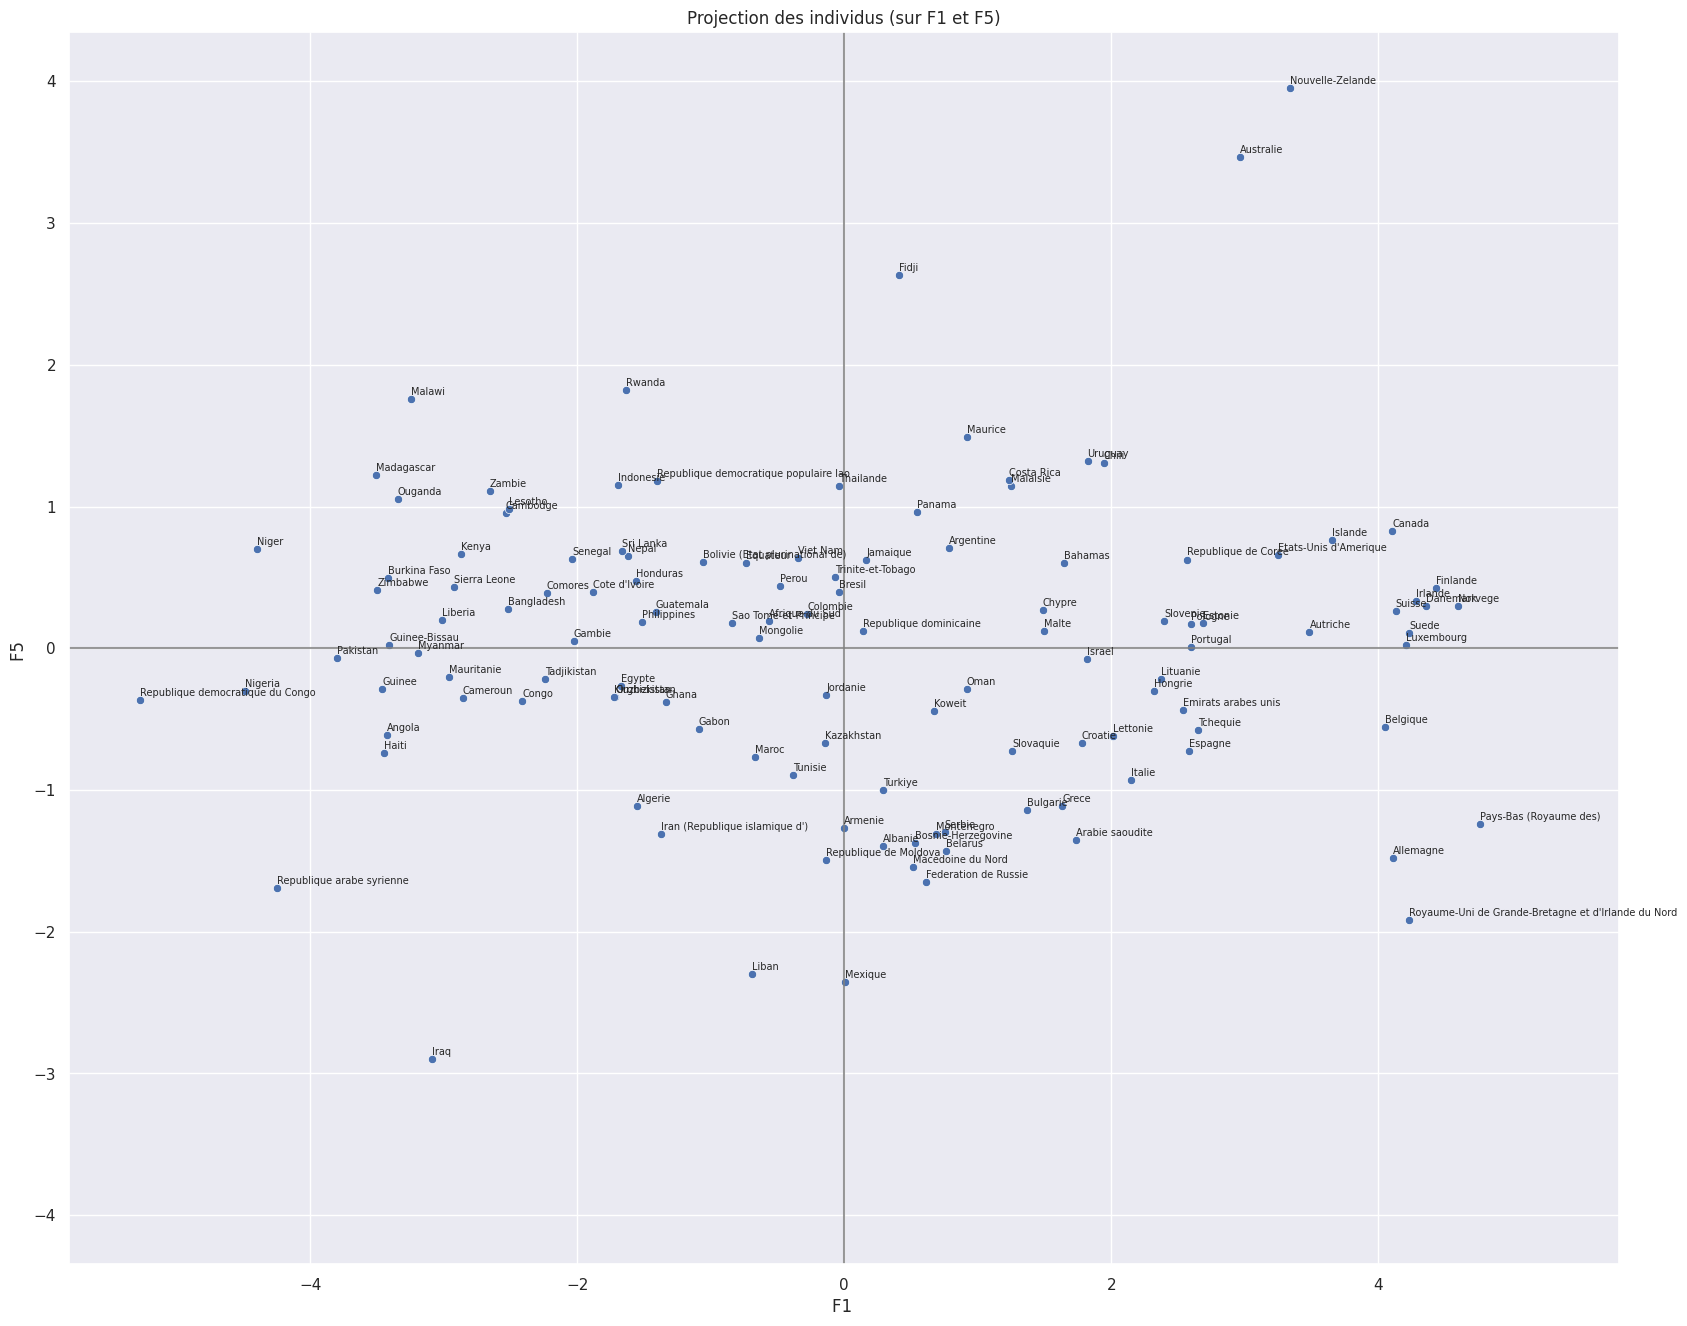

In [44]:
#Paramétrage des composantes
x_y = [0,4]

#Affichage du graph avec continents
display_factorial_planes(X_proj, x_y, labels=observations, figsize=[20,16])

# Etape 6 - Classification ascendante hiérarchique

## 6.1 - Linkage

In [45]:
Z = linkage(X_proj, method="ward")

## 6.2 - Dendrogram

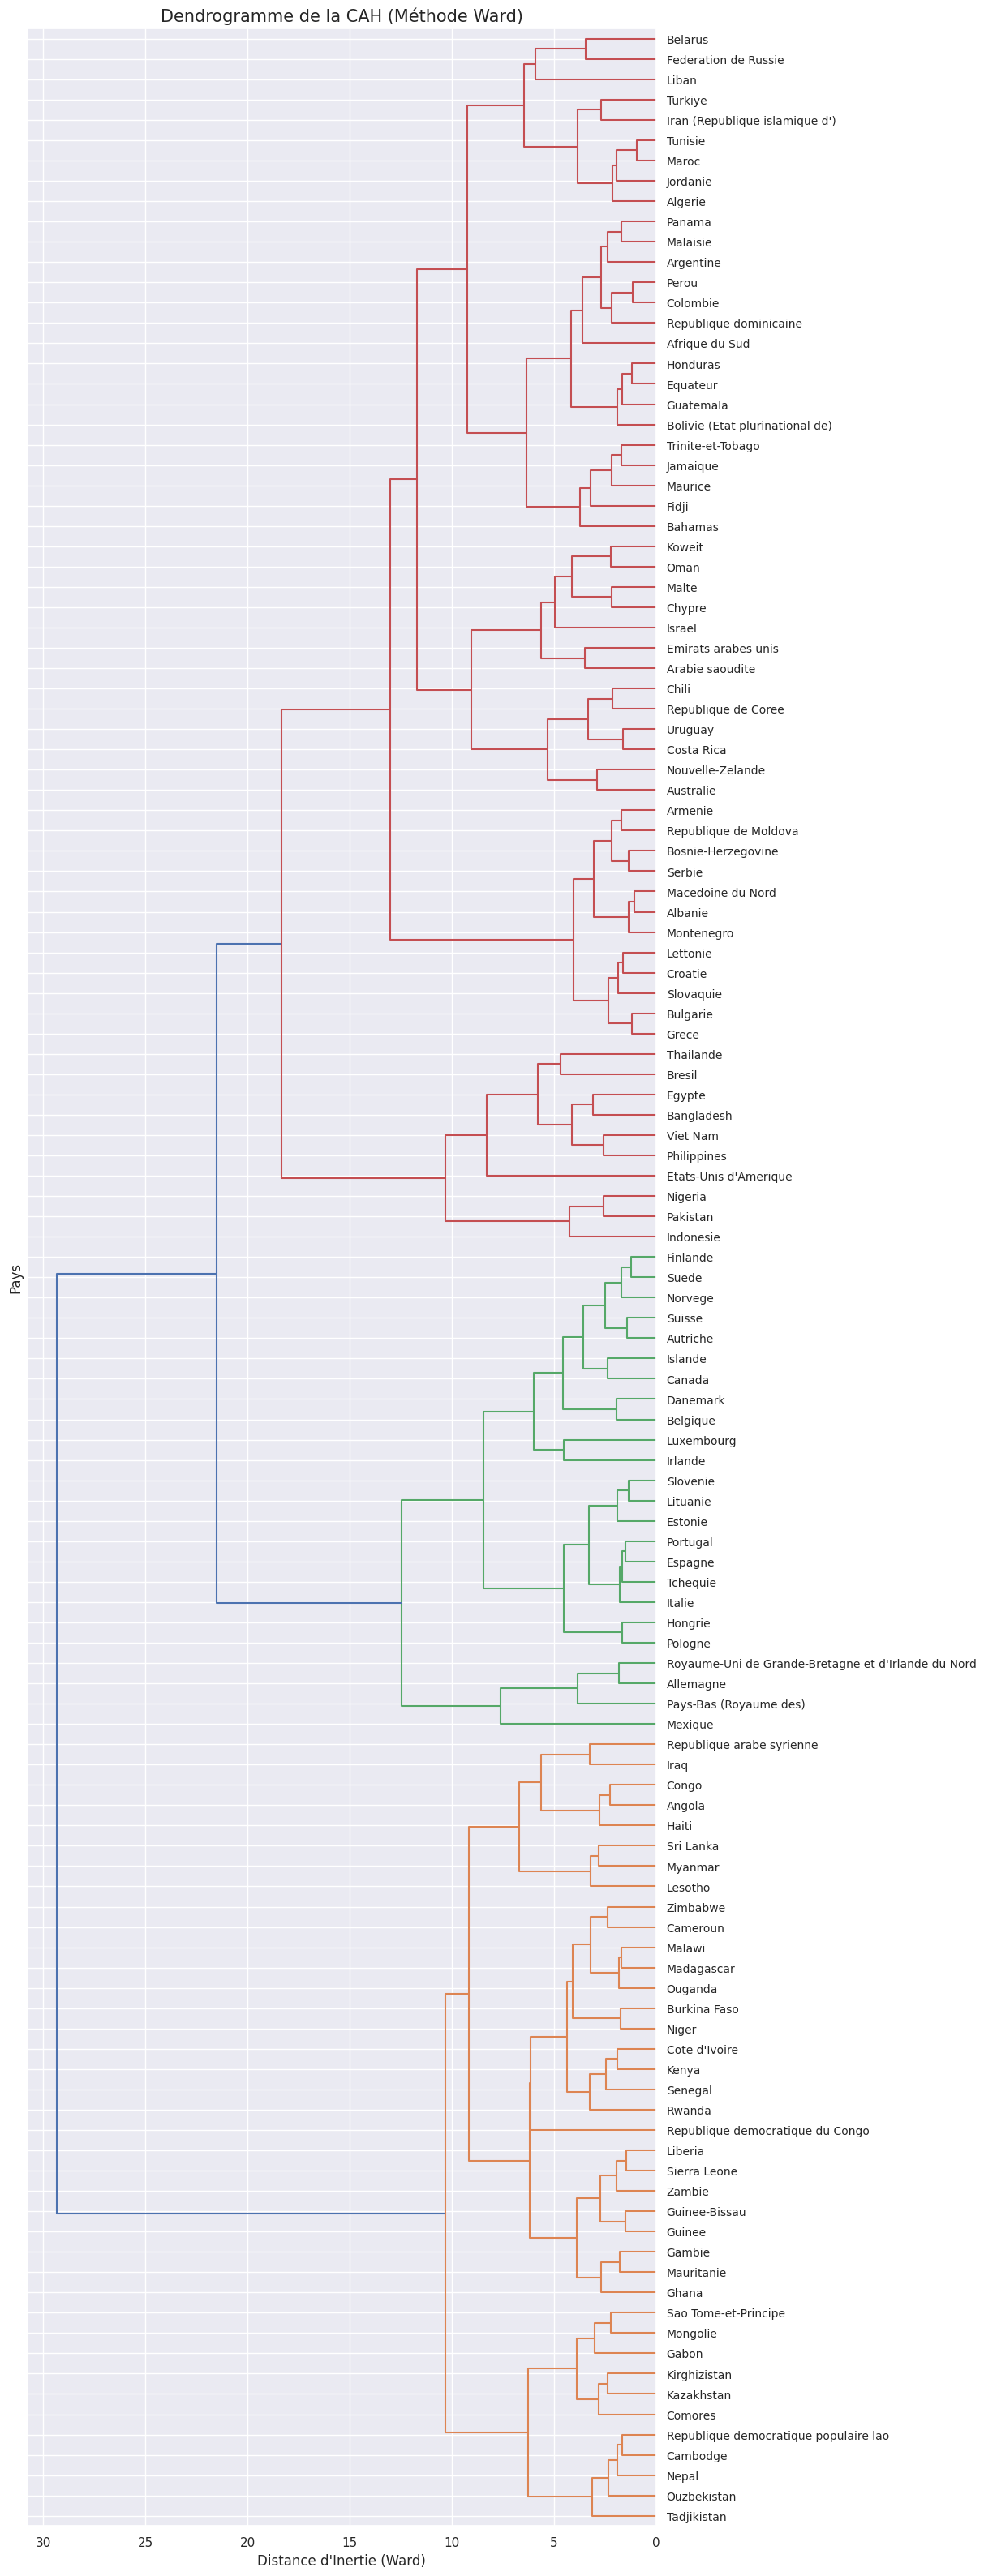

In [75]:
#Paramétrage
fig, ax = plt.subplots(1, 1, figsize=(10,40))

dendrogram(Z, ax=ax, labels=observations, orientation = "left", leaf_font_size=10)

#Affichage du graph
plt.title("Dendrogramme de la CAH (Méthode Ward)", fontsize=15)
ax.set_xlabel("Distance d'Inertie (Ward)", fontsize=12)
ax.set_ylabel("Pays", fontsize=12)
plt.show()

Nous "coupons" vers 12 de distance d'inertie ce qui nous donne un bon compromis entre la grandeur des échantillons et leurs différences, ce qui nous donne 5 clusters avec cette méthode.

## 6.3 - Clusters

In [47]:
#Nombre de clusters souhaité
k_cah=5

In [48]:
#Définition des clusters
clusters = fcluster(Z, k_cah, criterion='maxclust')
clusters

array([3, 3, 3, 3, 3, 3, 5, 2, 3, 3, 1, 3, 5, 5, 2, 3, 2, 5, 2, 1, 1, 5,
       5, 2, 1, 5, 5, 1, 2, 2, 5, 1, 1, 5, 5, 1, 5, 1, 1, 1, 1, 5, 1, 1,
       1, 1, 1, 1, 1, 5, 2, 5, 5, 1, 1, 1, 1, 1, 5, 5, 2, 1, 5, 5, 2, 2,
       5, 2, 4, 5, 1, 2, 5, 5, 2, 2, 1, 1, 1, 4, 4, 1, 2, 5, 2, 4, 2, 1,
       5, 2, 5, 1, 5, 5, 5, 4, 5, 1, 4, 4, 4, 5, 4, 2, 1, 1, 1, 2, 1, 4,
       4, 5, 2, 5, 5, 5, 1, 2, 4, 5, 5, 2, 1], dtype=int32)

In [49]:
#Création du dataframe avec les clusters
df_cah = pd.DataFrame(X_proj, index=observations, columns=[f"F{i+1}" for i in range(X_proj.shape[1])])
df_cah['cluster'] = clusters

## 6.4 - Analyse

### 6.4.1 - Comparaison des clusteurs dans les différents référentiels

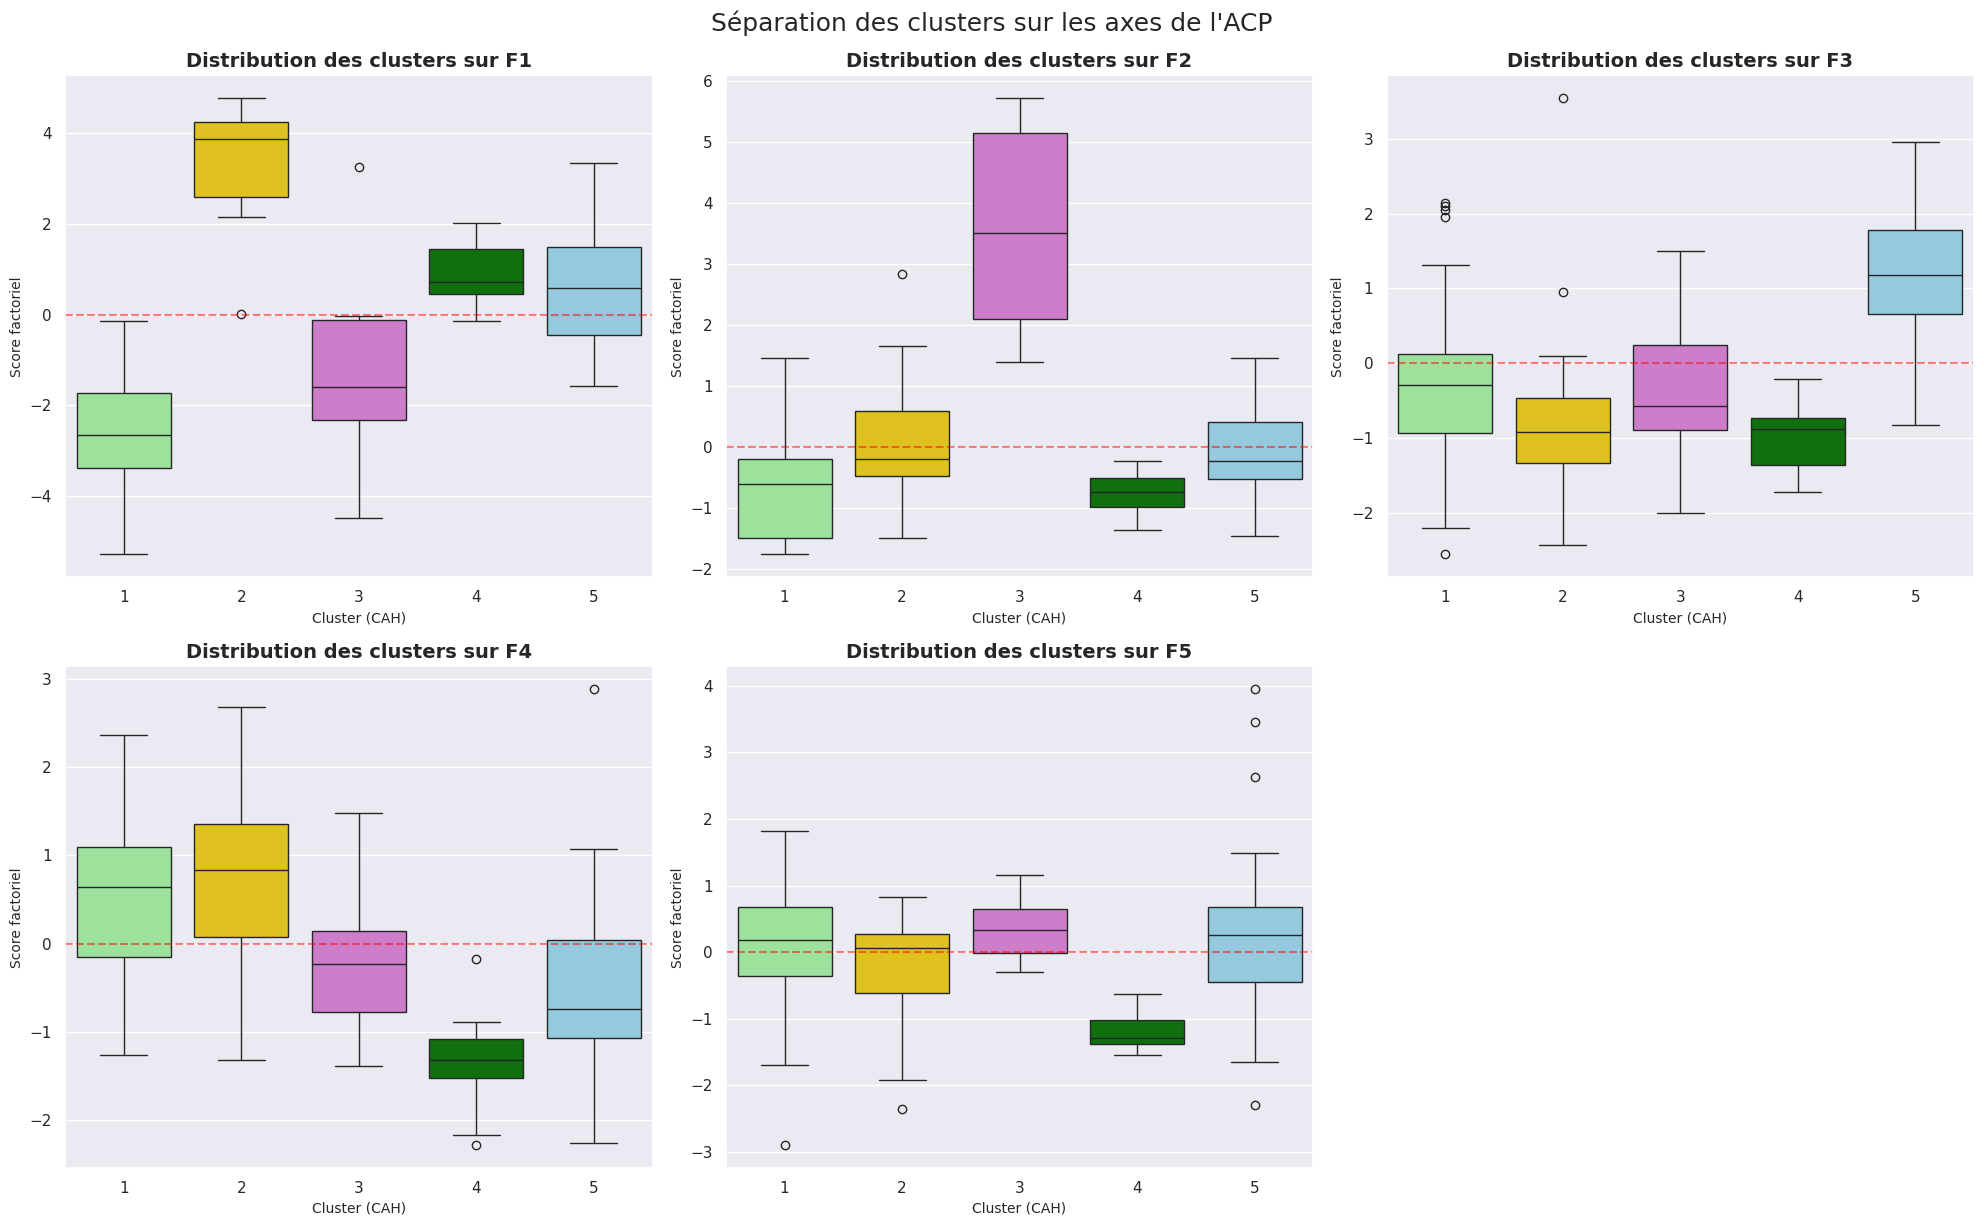

In [50]:
#Attribution de couleurs pour les clusters
palette_clusters = {
    1: "lightgreen",
    2: "gold",
    3: "orchid",
    4: "green",
    5: "skyblue",
}

axes_acp = ['F1', 'F2', 'F3', 'F4', 'F5']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, axe in enumerate(axes_acp):
    sns.boxplot(x='cluster', y=axe, data=df_cah, ax=axes[i], palette=palette_clusters, hue='cluster',legend=False)
    axes[i].set_title(f'Distribution des clusters sur {axe}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster (CAH)', fontsize=10)
    axes[i].set_ylabel('Score factoriel', fontsize=10)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne du "pays moyen"

axes[5].axis('off') # Cacher le 6ème graphique vide

plt.tight_layout()
plt.suptitle("Séparation des clusters sur les axes de l'ACP", fontsize=18, y=1.02)
plt.show()

Le cluster numéro 2 semble être celui correpondant le mieux à l'ensemble de l'analyse ACP.

### 6.4.2 - Projection des pays du cluster sélectionné sur F1 et F2

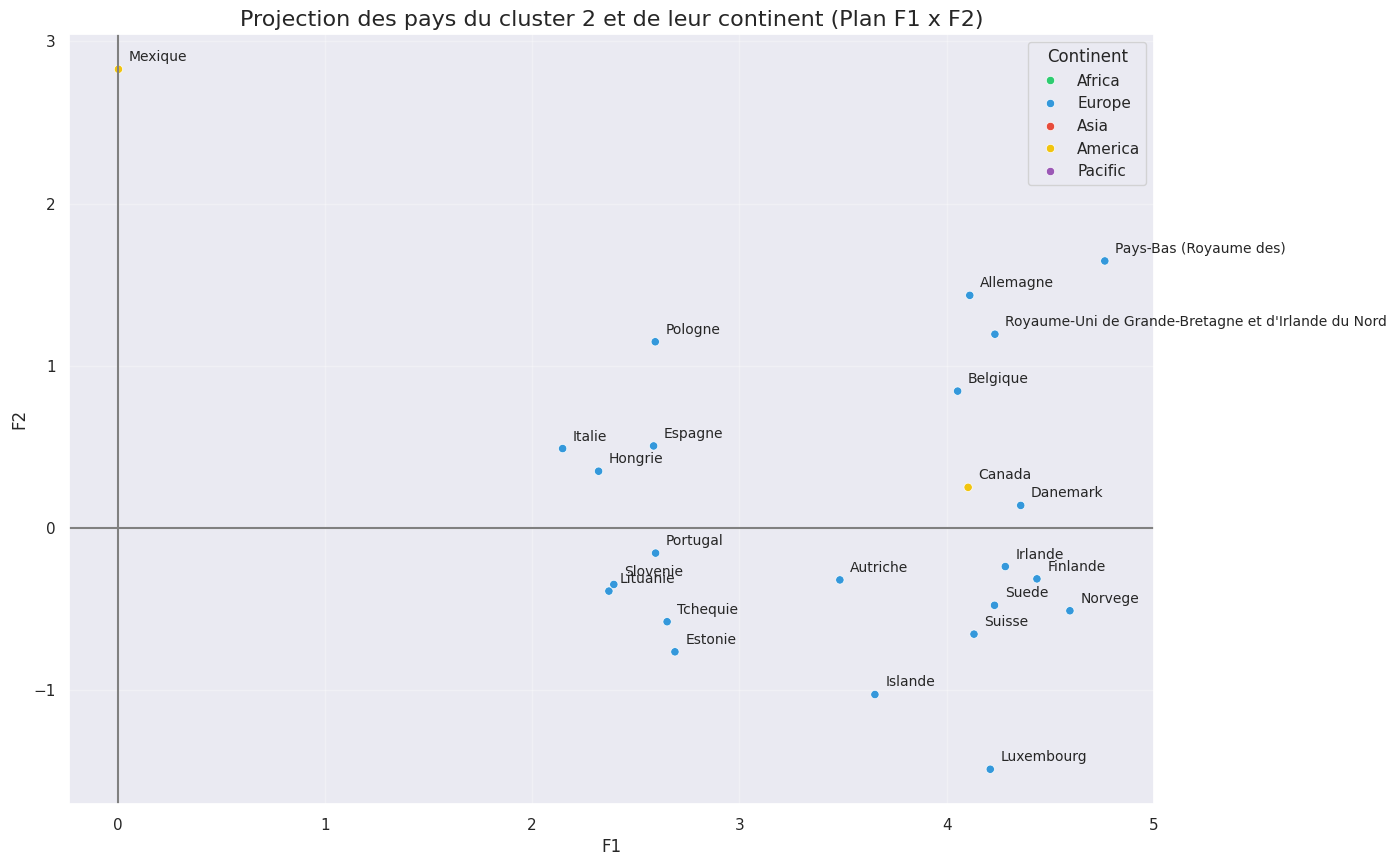

In [79]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F1', 'F2'
target_cluster = 2

cluster_data = df_cah[df_cah['cluster'] == 2]

#Couleur légende
couleurs_continents = {
    'Europe': '#3498db',        # Bleu
    'Africa': '#2ecc71',        # Vert
    'Asia': '#e74c3c',          # Rouge
    'America': '#f1c40f',      # Jaune
    'Pacific': '#9b59b6'        # Violet
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=cluster_data, x=d1, y=d2, hue=df_P11['Continent'], palette=couleurs_continents)

for i in range(cluster_data.shape[0]):
    plt.text(cluster_data.iloc[i][d1] + 0.05,
             cluster_data.iloc[i][d2] + 0.05,
             cluster_data.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays du cluster {target_cluster} et de leur continent (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()


Afin de respecter notre analyse ACP nous pouvons dans un premier temps sélectionner l'ensemble des pays en écartant le **Mexique** qui présente un score F2 beaucoup plus élevé ce qui en fait un pays avec un population importante mais avec un accès à de la nourriture de qualité compliqué, le score F1 erst également trop petit.
Nous pouvons également écarter le **Canada** qui ne se situe pas en Europe contrairement à tous les autres pays restants et qui apporte une contrainte logistique supplémentaire.

Pays à écarter :
* Mexique
* Canada

### 6.4.3 - Projection des pays du cluster sélectionné sur F3 et F4

In [52]:
#Pays écartés
pays_ecartes_cah = [
    "Canada",
    "Mexique"
]

#Création d'un nouveau dataframe avec les pays du cluster 4 sans ceux écartés avec CAH
df_cah_selection_1 = df_cah.loc[
    (df_cah['cluster'] == 2) &
    (~df_cah.index.isin(pays_ecartes_cah))
]

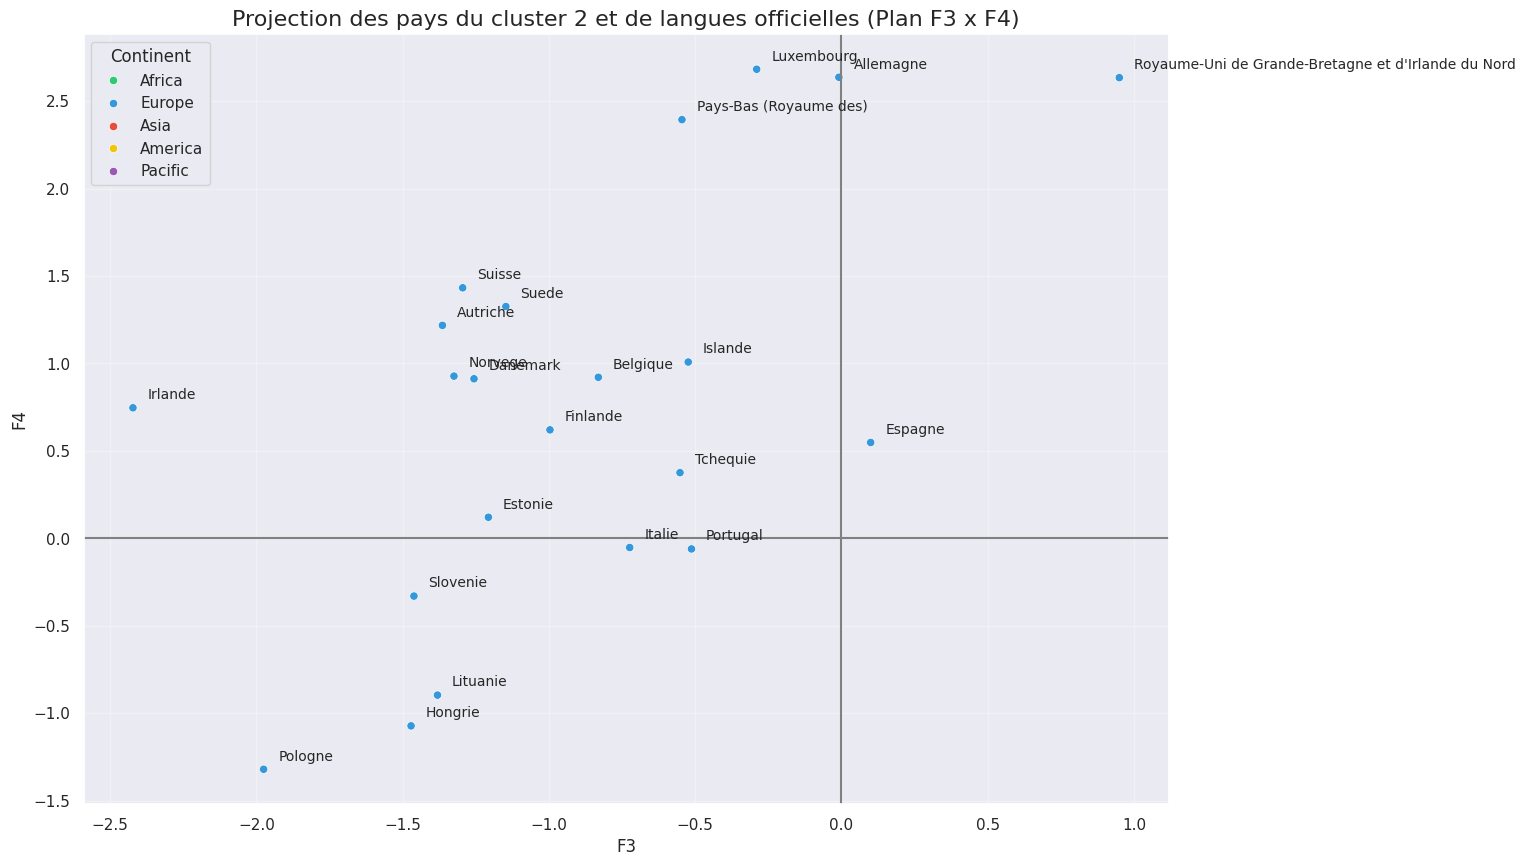

In [53]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F3', 'F4'
target_cluster = 2

cluster_data = df_cah_selection_1[df_cah_selection_1['cluster'] == 2]

#Couleur légende
couleurs_continents = {
    'Europe': '#3498db',        # Bleu
    'Africa': '#2ecc71',        # Vert
    'Asia': '#e74c3c',          # Rouge
    'America': '#f1c40f',      # Jaune
    'Pacific': '#9b59b6'        # Violet
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=cluster_data,
                x=d1,
                y=d2,
                hue=df_P11['Continent'],
                palette=couleurs_continents)

for i in range(cluster_data.shape[0]):
    plt.text(cluster_data.iloc[i][d1] + 0.05,
             cluster_data.iloc[i][d2] + 0.05,
             cluster_data.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays du cluster {target_cluster} et de langues officielles (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()


Conformément à l'analyse ACP nous pouvons écarter en plus des Etats-Unis et du Canada :
* Pologne
* Hongrie
* Lituanie
* Slovenie
* Italie
* Portugal

F4 négatif donc importation de viande de volaille limitée.

## 6.5 - Sélection des pays

### 6.5.1 - Nouveau dataframe

In [54]:
#Pays écartés
pays_ecartes_cah = [
    "Canada",
    "Mexique",
    "Pologne",
    "Hongrie",
    "Lituanie",
    "Slovenie",
    "Italie",
    "Portugal"
    ]

#Création d'un nouveau dataframe avec les pays du cluster 4 sans ceux écartés avec CAH
df_cah_selection_2 = df_cah.loc[
    (df_cah['cluster'] == 2) &
    (~df_cah.index.isin(pays_ecartes_cah))
]

In [55]:
print("\n--- Détail des pays cibles ---")
for pays in df_cah_selection_2.index:
    print(f"- {pays}")


--- Détail des pays cibles ---
- Allemagne
- Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
- Espagne
- Pays-Bas (Royaume des)
- Belgique
- Tchequie
- Suede
- Autriche
- Suisse
- Danemark
- Finlande
- Norvege
- Irlande
- Estonie
- Luxembourg
- Islande


### 6.5.2 - Projection et filtre

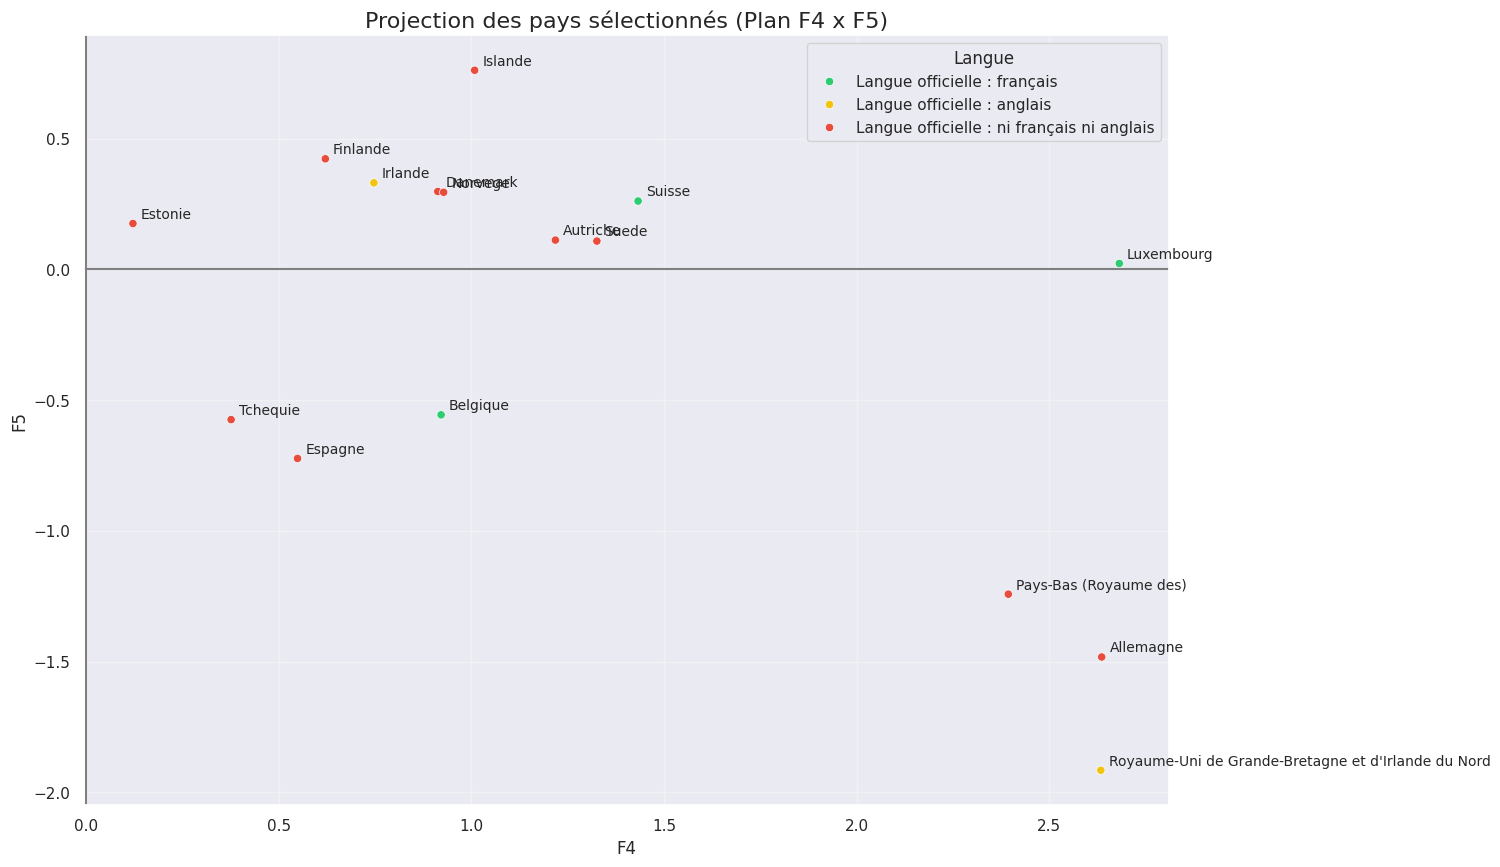

In [56]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F4', 'F5'

#Dénomination légende
temp_df = df_P11.copy()

Noms_langue = {
    0: 'Langue officielle : ni français ni anglais',
    1: 'Langue officielle : anglais',
    2: 'Langue officielle : français',
}

temp_df['Langue'] = temp_df['Score Langue'].map(Noms_langue)

#Couleur légende
couleurs_langue = {
    'Langue officielle : ni français ni anglais': '#e74c3c',        # Rouge
    'Langue officielle : anglais': '#f1c40f',        # Jaune
    'Langue officielle : français': '#2ecc71',          # Vert
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=df_cah_selection_2,
                x=d1,
                y=d2,
                hue=temp_df['Langue'],
                hue_order=['Langue officielle : français','Langue officielle : anglais','Langue officielle : ni français ni anglais'],
                palette=couleurs_langue)

for i in range(df_cah_selection_2.shape[0]):
    plt.text(df_cah_selection_2.iloc[i][d1] + 0.02,
             df_cah_selection_2.iloc[i][d2] + 0.02,
             df_cah_selection_2.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays sélectionnés (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()


En ajoutant l'axe F5 pour la prise en compte de la distance nous avons une vision complète pour sélectionner une liste restreinte de pays à envisager pour le développement commercial divisés en 2 groupes en fonction de la stratégie commerciale et marketing.

Pays francophones :
* Suisse
* Belgique
* Luxembourg

Pays anglophones :
* Royaume-Uni (langue officielle)
* Allemagne (excellent niveau Indice de maîtrise de l'anglais EF EPI)
* Pays-Bas (excellent niveau Indice de maîtrise de l'anglais EF EPI)


# Etape 7 - K-means

## 7.1 - Clusters

In [82]:
df_kmeans = pd.DataFrame(
    X_proj,
    index=df_P11.index,
    columns=[f"F{i+1}" for i in range(X_proj.shape[1])]
)

df_kmeans

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16
Pays,,,,,,,,,,,,,,,,
Etats-Unis d'Amerique,3.252119,4.705882,0.775537,0.363184,0.659869,-0.814694,-0.909424,-0.035294,-1.349488,-1.086036,-0.793308,-0.602278,2.549421,-0.676277,-1.017592,0.014925
Indonesie,-1.692448,5.716380,-0.350921,-0.277696,1.154987,-1.621656,-1.547080,-0.567606,0.900341,0.156263,0.465680,0.138938,0.166348,0.019222,0.140870,-0.217711
Pakistan,-3.797177,5.319666,-1.069858,0.167938,-0.072048,-1.272134,-1.572210,0.313503,0.686718,0.385995,-0.578709,0.760153,-0.735655,0.024069,-0.266977,-0.011678
Nigeria,-4.485156,5.281666,-0.818773,1.482052,-0.302891,-0.597282,-2.553354,0.700796,0.967973,-0.358007,0.426067,0.878040,-1.049510,0.591891,0.468641,0.024346
Bresil,-0.039186,3.683220,1.496568,-1.384629,0.395490,-0.144619,-0.776029,0.828503,-0.346086,-0.654671,0.637955,0.318573,0.867810,-0.186110,-0.075564,0.008362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Montenegro,0.690683,-1.289684,-0.589951,-0.886931,-1.310562,-0.979060,-0.870212,-0.522560,0.254041,-0.206191,-0.097555,-0.310353,-0.229877,-0.352837,0.029499,-0.015008
Malte,1.498365,-1.453900,-0.116928,1.071978,0.123302,-1.581455,-0.426941,1.017050,-0.136785,0.617578,0.088766,0.648417,0.173457,0.038738,-0.423699,0.372015
Bahamas,1.648001,-1.205457,2.414973,-1.004532,0.602510,-1.516977,-0.549002,0.415092,0.068918,-1.080513,-0.337422,0.521304,-0.418853,-0.147333,-0.262251,-0.657941


## 7.2 - Méthode du coude

In [83]:
#Liste de stockage des inerties
inertie = []

In [84]:
#Liste du nombre de clusters à tester
k_list = range(1, n_components+1)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

In [85]:
#Entraînement de k-means
for i in k_list :
  kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
  kmeans.fit_predict(X_proj)
  inertie.append(kmeans.inertia_)

inertie

[1968.0000000000007,
 1434.2594835260902,
 1219.4159458846943,
 1090.9911716273787,
 992.170617764499,
 925.8274271783271,
 858.5386986550589,
 812.9565594219197,
 771.6927276379196,
 739.5439783231573,
 702.4222268537839,
 662.2664007624687,
 649.2293700478027,
 628.1954634226034,
 580.6856462569823,
 556.7192130454374]

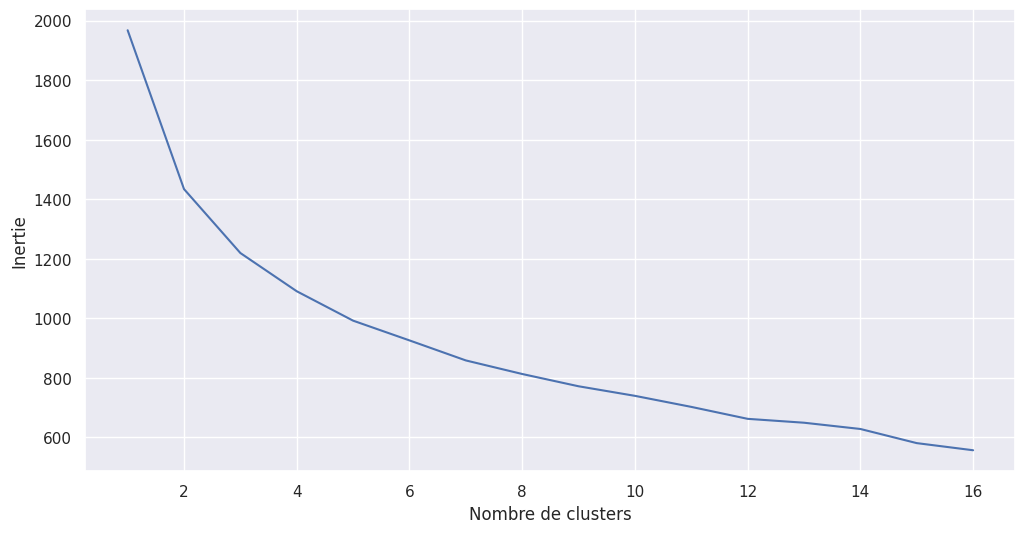

In [86]:
#Graphique
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("Inertie")
ax.set_xlabel("Nombre de clusters")
ax = plt.plot(k_list, inertie)

D'après la courbe nous pouvons choisir entre 4 et 5 clusters.

## 7.3 - Score de silhouette

In [87]:
#Comparaison des scores de silouhette
scores_silhouette = {}

for k in range(2,n_components+1):
  kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
  kmeans_labels = kmeans.fit_predict(X_proj)

  score = silhouette_score(X_proj, kmeans_labels)
  scores_silhouette[k] = score
  print(f"Score de silhouette pour {k} clusters : {score:.4f}")

Score de silhouette pour 2 clusters : 0.2380
Score de silhouette pour 3 clusters : 0.1901
Score de silhouette pour 4 clusters : 0.2056
Score de silhouette pour 5 clusters : 0.2035
Score de silhouette pour 6 clusters : 0.1698
Score de silhouette pour 7 clusters : 0.1723
Score de silhouette pour 8 clusters : 0.1751
Score de silhouette pour 9 clusters : 0.1642
Score de silhouette pour 10 clusters : 0.1758
Score de silhouette pour 11 clusters : 0.1704
Score de silhouette pour 12 clusters : 0.1585
Score de silhouette pour 13 clusters : 0.1784
Score de silhouette pour 14 clusters : 0.1659
Score de silhouette pour 15 clusters : 0.1609
Score de silhouette pour 16 clusters : 0.1770


Le choix statistique serait de prendre 2 clusters (score de silhouette plus élevé) mais nous choisissons une segmentation en 4 groupes qui offre une bonne stabilité statistique et une analyse plus fine du marché.

## 7.3 - Clusters

In [88]:
#Réentraînement de l'estimateur
kmeans = KMeans(n_clusters=4)
kmeans.fit(X_proj)

KMeans(n_clusters=4)

In [89]:
#Clusters
kmeans.labels_

array([0, 1, 1, 1, 3, 1, 3, 2, 1, 1, 1, 3, 2, 3, 0, 3, 0, 2, 0, 1, 1, 0,
       3, 0, 1, 2, 3, 2, 0, 0, 3, 2, 1, 3, 3, 1, 3, 1, 1, 1, 1, 0, 1, 1,
       1, 2, 1, 1, 3, 3, 0, 3, 3, 1, 1, 1, 1, 1, 3, 3, 0, 2, 3, 3, 0, 0,
       3, 0, 3, 0, 1, 0, 3, 3, 0, 0, 1, 1, 1, 3, 3, 2, 0, 2, 0, 3, 0, 1,
       0, 0, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 1, 2, 1, 0, 1, 3,
       3, 3, 0, 3, 3, 3, 1, 0, 3, 3, 3, 0, 3], dtype=int32)

In [90]:
#Création de la colonne 'clusters'
df_kmeans['cluster'] = kmeans.labels_
df_kmeans

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,cluster
Pays,,,,,,,,,,,,,,,,,
Etats-Unis d'Amerique,3.252119,4.705882,0.775537,0.363184,0.659869,-0.814694,-0.909424,-0.035294,-1.349488,-1.086036,-0.793308,-0.602278,2.549421,-0.676277,-1.017592,0.014925,0
Indonesie,-1.692448,5.716380,-0.350921,-0.277696,1.154987,-1.621656,-1.547080,-0.567606,0.900341,0.156263,0.465680,0.138938,0.166348,0.019222,0.140870,-0.217711,1
Pakistan,-3.797177,5.319666,-1.069858,0.167938,-0.072048,-1.272134,-1.572210,0.313503,0.686718,0.385995,-0.578709,0.760153,-0.735655,0.024069,-0.266977,-0.011678,1
Nigeria,-4.485156,5.281666,-0.818773,1.482052,-0.302891,-0.597282,-2.553354,0.700796,0.967973,-0.358007,0.426067,0.878040,-1.049510,0.591891,0.468641,0.024346,1
Bresil,-0.039186,3.683220,1.496568,-1.384629,0.395490,-0.144619,-0.776029,0.828503,-0.346086,-0.654671,0.637955,0.318573,0.867810,-0.186110,-0.075564,0.008362,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Montenegro,0.690683,-1.289684,-0.589951,-0.886931,-1.310562,-0.979060,-0.870212,-0.522560,0.254041,-0.206191,-0.097555,-0.310353,-0.229877,-0.352837,0.029499,-0.015008,3
Malte,1.498365,-1.453900,-0.116928,1.071978,0.123302,-1.581455,-0.426941,1.017050,-0.136785,0.617578,0.088766,0.648417,0.173457,0.038738,-0.423699,0.372015,3
Bahamas,1.648001,-1.205457,2.414973,-1.004532,0.602510,-1.516977,-0.549002,0.415092,0.068918,-1.080513,-0.337422,0.521304,-0.418853,-0.147333,-0.262251,-0.657941,3


## 7.4 - Analyse

### 7.4.1 - Comparaison des clusteurs dans les différents référentiels

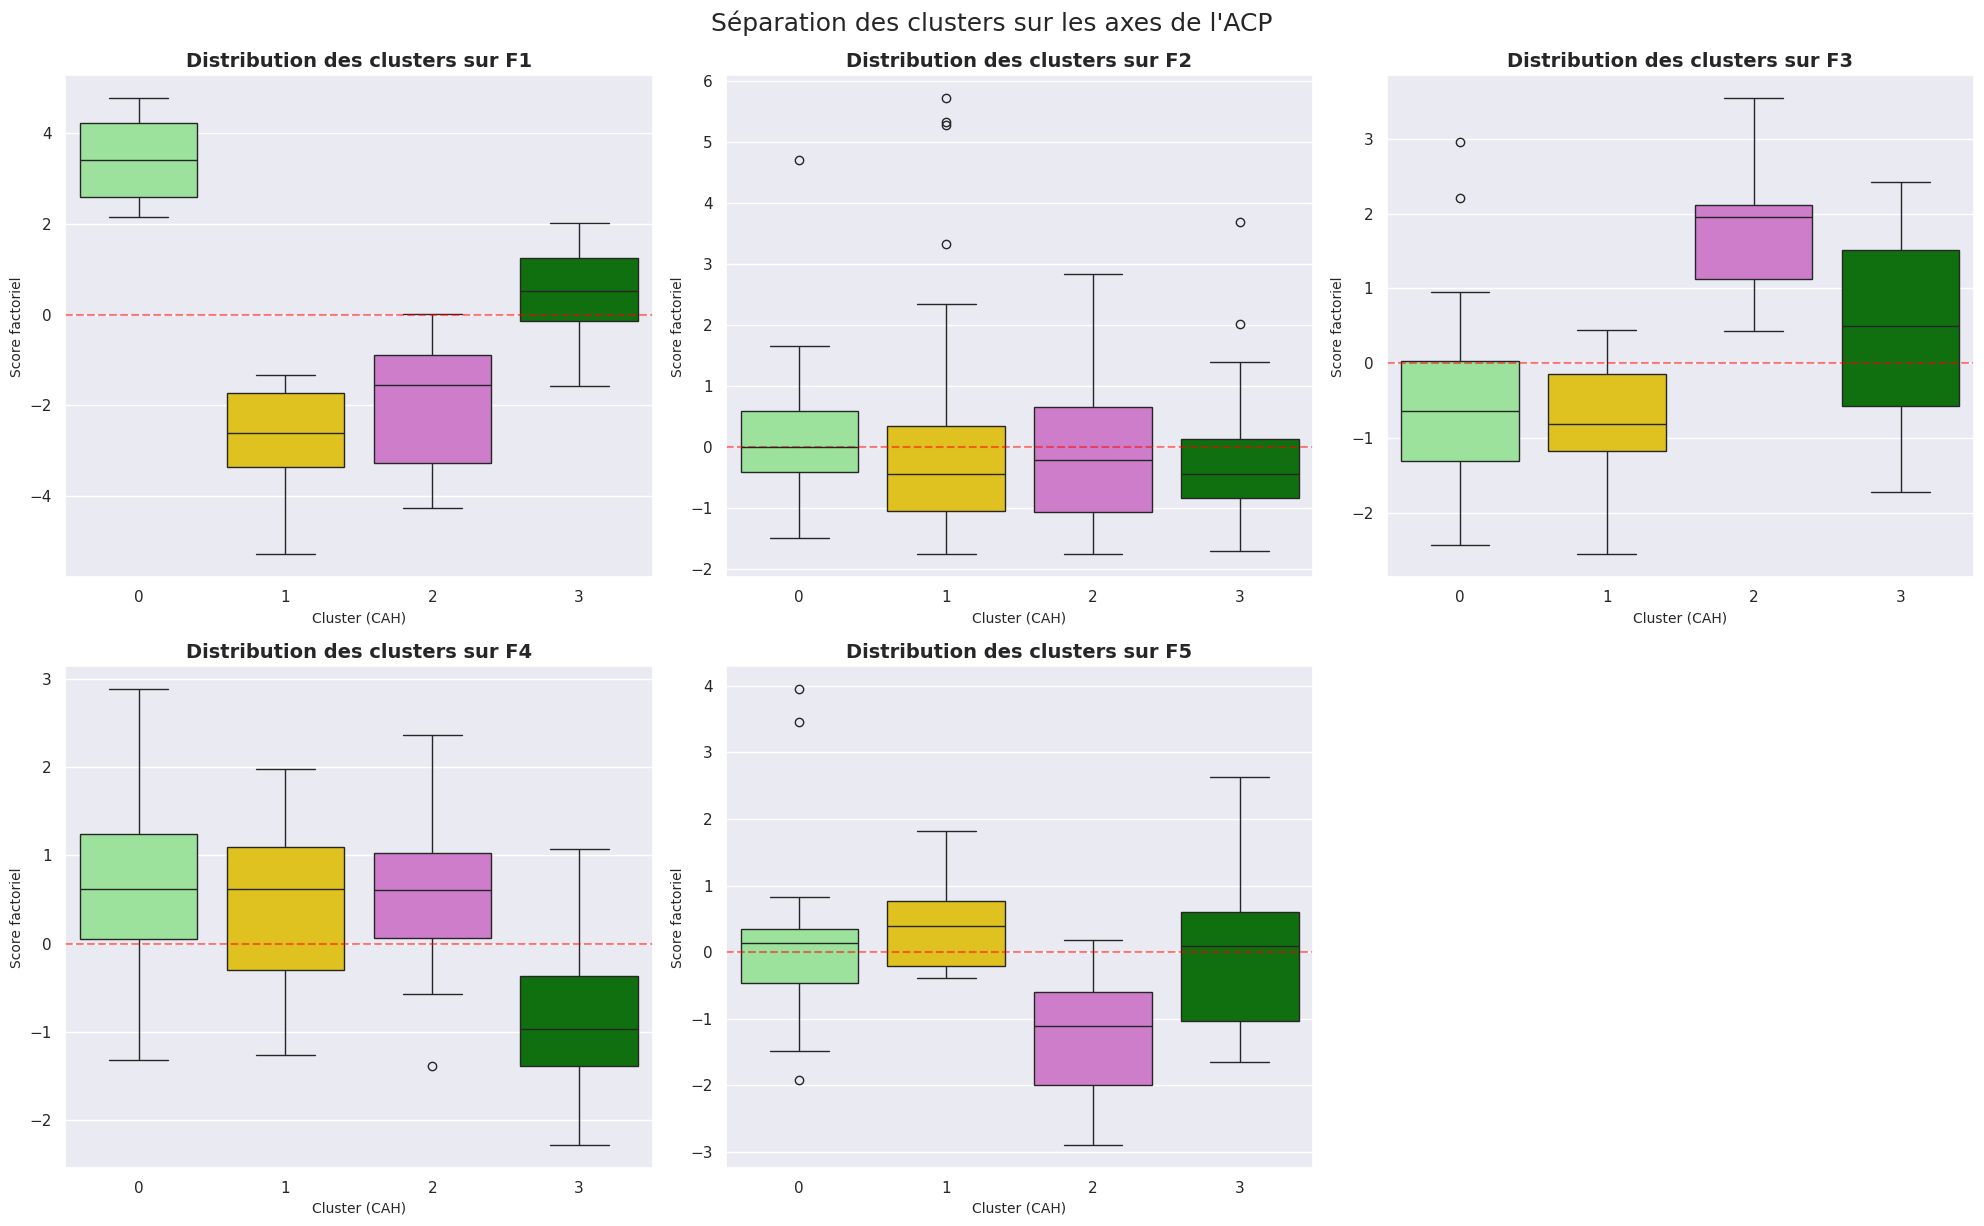

In [91]:
#Attribution de couleurs pour les clusters
palette_clusters = {
    0: "lightgreen",
    1: "gold",
    2: "orchid",
    3: "green",
}

axes_acp = ['F1', 'F2', 'F3', 'F4', 'F5']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, axe in enumerate(axes_acp):
    sns.boxplot(x='cluster', y=axe, data=df_kmeans, ax=axes[i], palette=palette_clusters, hue='cluster',legend=False)
    axes[i].set_title(f'Distribution des clusters sur {axe}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster (CAH)', fontsize=10)
    axes[i].set_ylabel('Score factoriel', fontsize=10)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne du "pays moyen"

axes[5].axis('off') # Cacher le 6ème graphique vide

plt.tight_layout()
plt.suptitle("Séparation des clusters sur les axes de l'ACP", fontsize=18, y=1.02)
plt.show()

Le cluster 0 semble être celui correspondant le mieux à l'analyse ACP.

### 7.4.2 - Projection des pays du cluster sélectionné sur F1 et F2

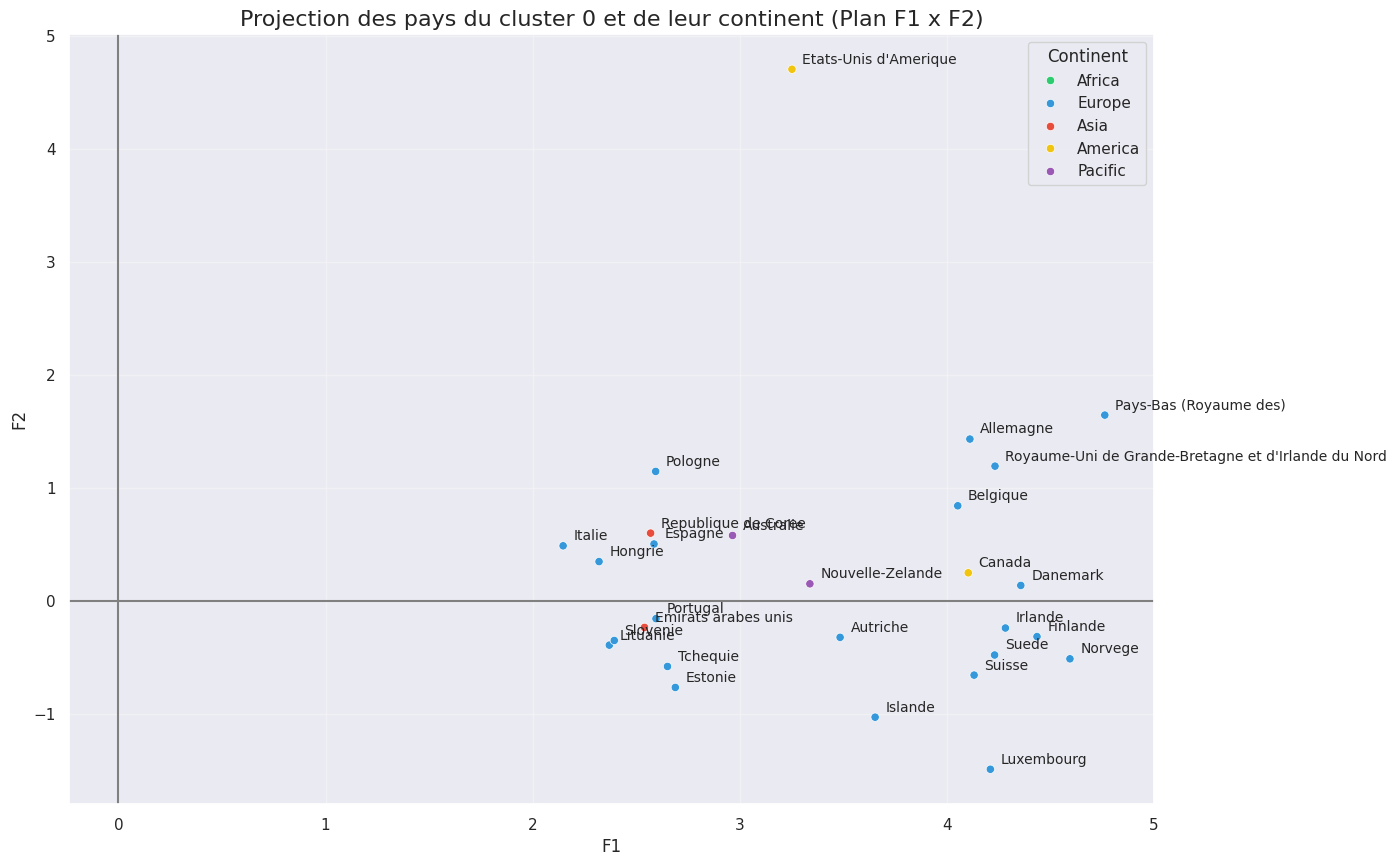

In [92]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F1', 'F2'
target_cluster = 0

cluster_data = df_kmeans[df_kmeans['cluster'] == 0]

#Couleur légende
couleurs_continents = {
    'Europe': '#3498db',        # Bleu
    'Africa': '#2ecc71',        # Vert
    'Asia': '#e74c3c',          # Rouge
    'America': '#f1c40f',      # Jaune
    'Pacific': '#9b59b6'        # Violet
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=cluster_data, x=d1, y=d2, hue=df_P11['Continent'], palette=couleurs_continents)

for i in range(cluster_data.shape[0]):
    plt.text(cluster_data.iloc[i][d1] + 0.05,
             cluster_data.iloc[i][d2] + 0.05,
             cluster_data.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays du cluster {target_cluster} et de leur continent (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

Afin de respecter notre analyse ACP nous pouvons dans un premier temps sélectionner l'ensemble des pays en écartant les **Etats-Unis** qui présentent un score F2 beaucoup plus élevé ce qui en fait un pays avec un population importante mais avec un accès à de la nourriture de qualité compliqué, le score F1 erst également trop petit.
Nous pouvons également écarter le **Canada**, Les ** Emirats Arabes Unis**, La **Republique de Coree**, l'**Australie** et la **Nouvelle-Zelande** qui ne se situent pas en Europe contrairement à tous les autres pays restants et qui apportent une contrainte logistique supplémentaire.

Les pays à écarter :
* Etats-Unis d'Amerique
* Canada
* Emirats arabes unis
* Republique de Coree
* Nouvelle-Zelande
* Australie

### 7.4.2 - Projection des pays du cluster sélectionné sur F3 et F4

In [93]:
#Pays écartés
pays_ecartes_kmeans = [
    "Canada",
    "Etats-Unis d'Amerique",
    "Emirats arabes unis",
    "Republique de Coree",
    "Nouvelle-Zelande",
    "Australie"
]

#Création d'un nouveau dataframe avec les pays du cluster 4 sans ceux écartés avec CAH
df_kmeans_selection_1 = df_kmeans.loc[
    (df_kmeans['cluster'] == 0) &
    (~df_kmeans.index.isin(pays_ecartes_kmeans))
]

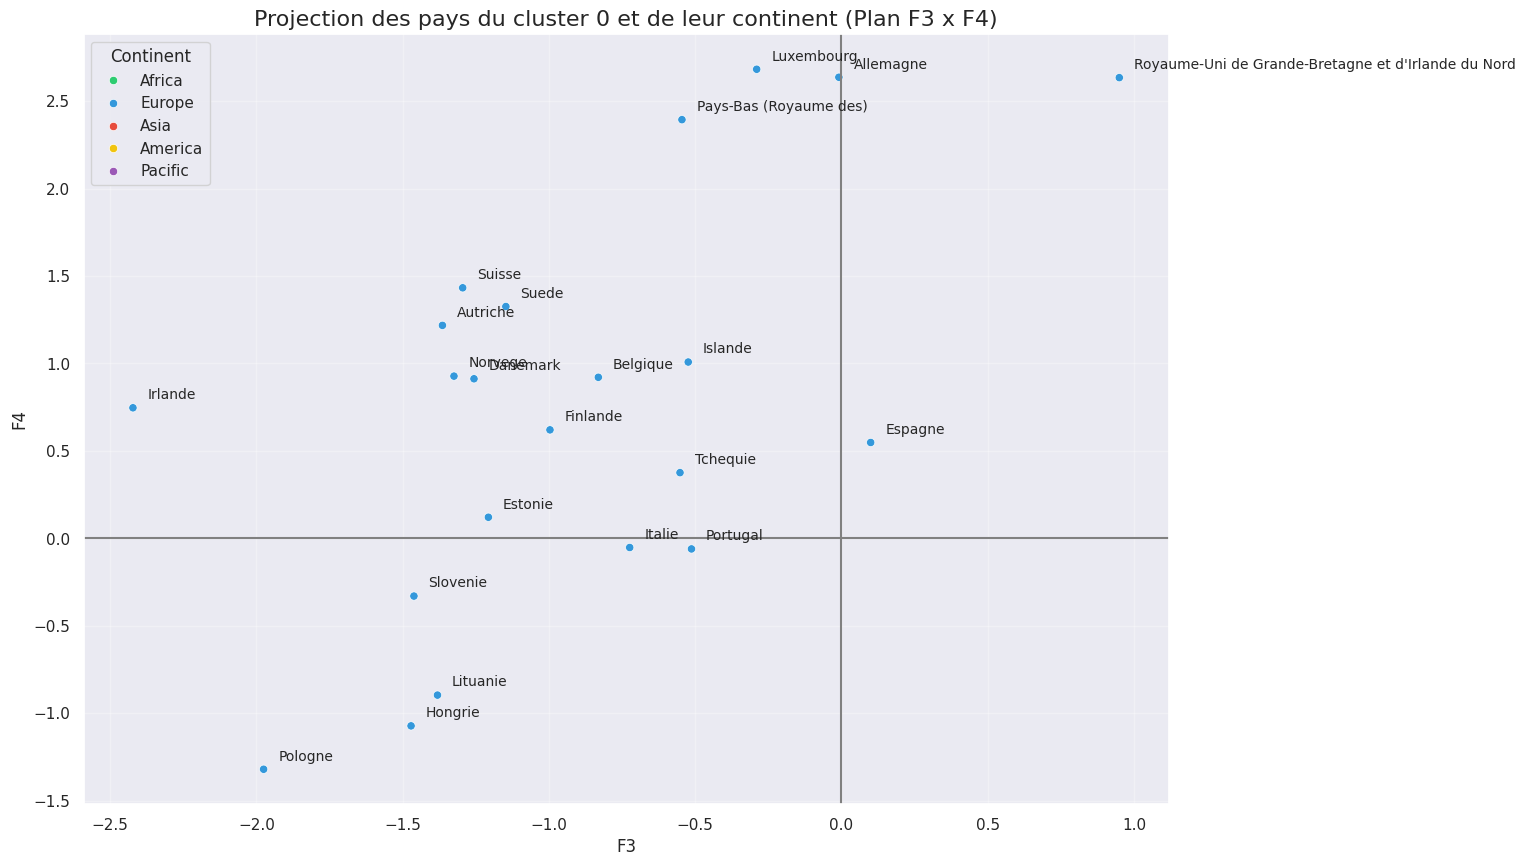

In [94]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F3', 'F4'
target_cluster = 0

cluster_data = df_kmeans_selection_1[df_kmeans_selection_1['cluster'] == 0]

#Couleur légende
couleurs_continents = {
    'Europe': '#3498db',        # Bleu
    'Africa': '#2ecc71',        # Vert
    'Asia': '#e74c3c',          # Rouge
    'America': '#f1c40f',      # Jaune
    'Pacific': '#9b59b6'        # Violet
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=cluster_data, x=d1, y=d2, hue=df_P11['Continent'], palette=couleurs_continents)

for i in range(cluster_data.shape[0]):
    plt.text(cluster_data.iloc[i][d1] + 0.05,
             cluster_data.iloc[i][d2] + 0.05,
             cluster_data.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays du cluster {target_cluster} et de leur continent (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

Conformément à l'analyse ACP nous pouvons écarter en plus des pays précédents:
* Portugal
* Hongrie
* Lituanie
* Slovenie
* Italie
* Pologne

F4 négatif donc importation de viande de volaille limitée

## 7.5 - Sélection des pays

### 7.5.1 - Nouveau dataframe

In [96]:
#Pays écartés
pays_ecartes_kmeans = [
    "Canada",
    "Etats-Unis d'Amerique",
    "Emirats arabes unis",
    "Republique de Coree",
    "Nouvelle-Zelande",
    "Australie",
    "Portugal",
    "Hongrie",
    "Lituanie",
    "Slovenie",
    "Italie",
    "Pologne"
]

#Création d'un nouveau dataframe avec les pays du cluster 4 sans ceux écartés avec CAH
df_kmeans_selection_2 = df_kmeans.loc[
    (df_kmeans['cluster'] == 0) &
    (~df_kmeans.index.isin(pays_ecartes_kmeans))
]

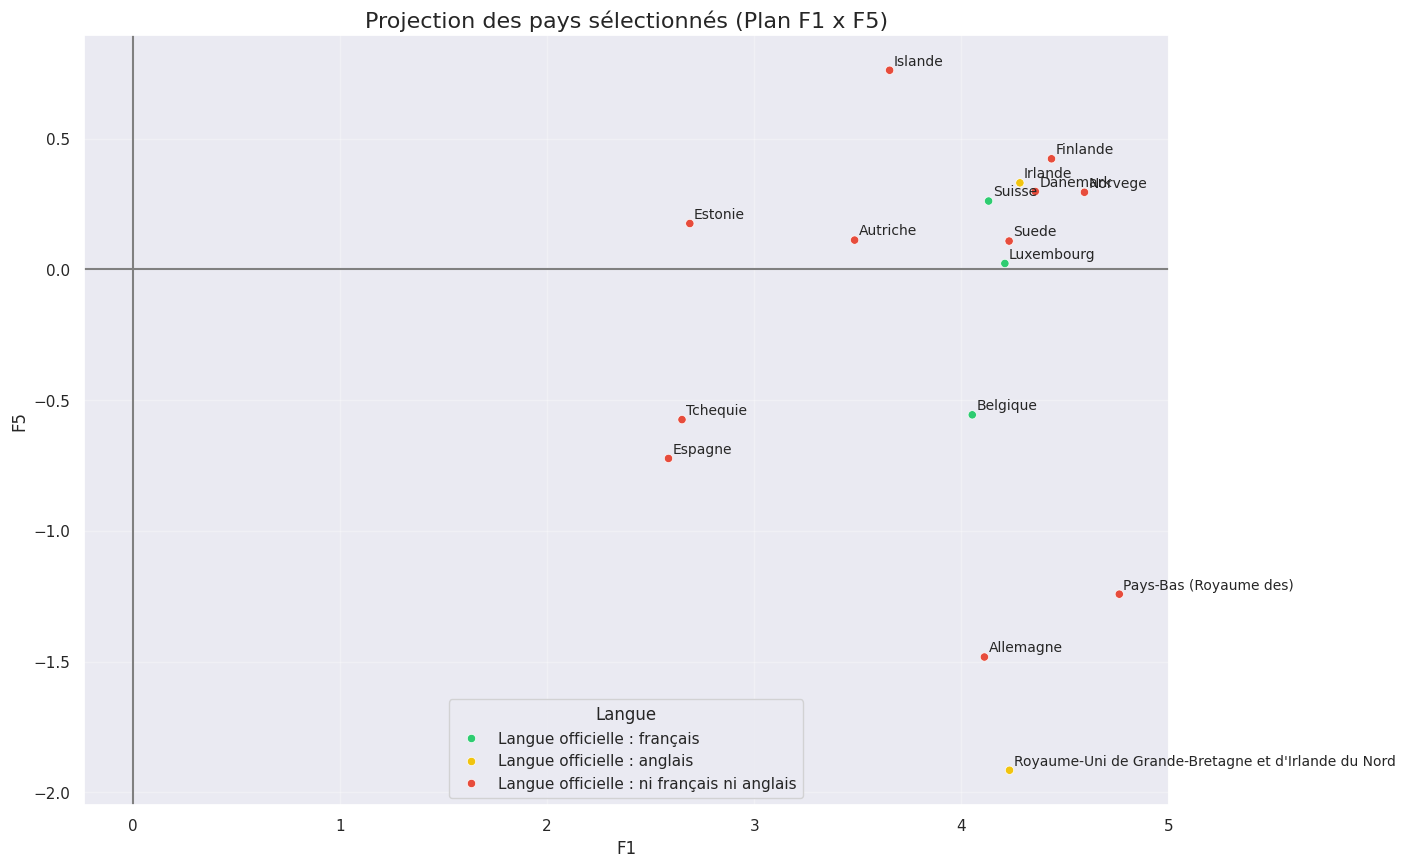

In [97]:
#Paramétrage des plans et du cluster sélectionné
d1, d2 = 'F1', 'F5'

#Dénomination légende
temp_df = df_P11.copy()

Noms_langue = {
    0: 'Langue officielle : ni français ni anglais',
    1: 'Langue officielle : anglais',
    2: 'Langue officielle : français',
}

temp_df['Langue'] = temp_df['Score Langue'].map(Noms_langue)

#Couleur légende
couleurs_langue = {
    'Langue officielle : ni français ni anglais': '#e74c3c',        # Rouge
    'Langue officielle : anglais': '#f1c40f',        # Jaune
    'Langue officielle : français': '#2ecc71',          # Vert
}

#Graph
plt.figure(figsize=(14, 10))

sns.scatterplot(data=df_kmeans_selection_2,
                x=d1,
                y=d2,
                hue=temp_df['Langue'],
                hue_order=['Langue officielle : français','Langue officielle : anglais','Langue officielle : ni français ni anglais'],
                palette=couleurs_langue)

for i in range(df_kmeans_selection_2.shape[0]):
    plt.text(df_kmeans_selection_2.iloc[i][d1] + 0.02,
             df_kmeans_selection_2.iloc[i][d2] + 0.02,
             df_kmeans_selection_2.index[i],
             fontsize=10)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'Projection des pays sélectionnés (Plan {d1} x {d2})', fontsize=16)
plt.xlabel(f'{d1}', fontsize=12)
plt.ylabel(f'{d2}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

En ajoutant l'axe F5 pour la prise en compte de la distance nous avons une vision complète pour sélectionner une liste restreinte de pays à envisager pour le développement commercial divisés en 2 groupes en fonction de la stratégie commerciale et marketing.

Pays francophones :
* Suisse
* Belgique
* Luxembourg

Pays anglophones :
* Royaume-Uni (langue officielle)
* Allemagne (excellent niveau Indice de maîtrise de l'anglais EF EPI)
* Pays-Bas (excellent niveau Indice de maîtrise de l'anglais EF EPI)
